# feature exploration on the benchmark network

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

In [2]:
ts_all = pd.read_csv('../data/timeseries.csv', parse_dates=['date'])
meta_all = pd.read_csv('../data/dataset.csv')
bench = pd.read_csv('../data/benchmark.csv')

train_all = pd.read_feather('../checkpoints/train_data.feather')
train_all['date'] = pd.to_datetime(train_all['date'])

bench_ids = bench['Station'].tolist()

ts = ts_all[ts_all['station_id'].isin(bench_ids)].copy()
meta = meta_all[meta_all['id'].isin(bench_ids)].copy()
train = train_all[train_all['station_id'].isin(bench_ids)].copy()

print(f'Full dataset:    {ts_all["station_id"].nunique()} stations')
print(f'Benchmark set:   {len(bench_ids)} stations (NRFA near-natural, high-quality)')
print(f'Matched in ts:   {ts["station_id"].nunique()} stations')
print(f'Matched in meta: {len(meta)} stations')
print(f'Matched in train:{train["station_id"].nunique()} stations')
print(f'\nTimeseries:  {ts.shape}')
print(f'Metadata:    {meta.shape} ({len(meta.columns)} descriptors)')
print(f'Train:       {train.shape}')
print(f'Date range:  {ts["date"].min().date()} to {ts["date"].max().date()}')

Full dataset:    1396 stations
Benchmark set:   146 stations (NRFA near-natural, high-quality)
Matched in ts:   146 stations
Matched in meta: 146 stations
Matched in train:146 stations

Timeseries:  (1638128, 4)
Metadata:    (146, 109) (109 descriptors)
Train:       (1279836, 42)
Date range:  1994-01-01 to 2024-09-30


In [3]:
station_stats = ts.groupby('station_id')['flow'].agg(['mean', 'std', 'count'])
station_stats = station_stats[station_stats['count'] > 365]  # At least 1 year

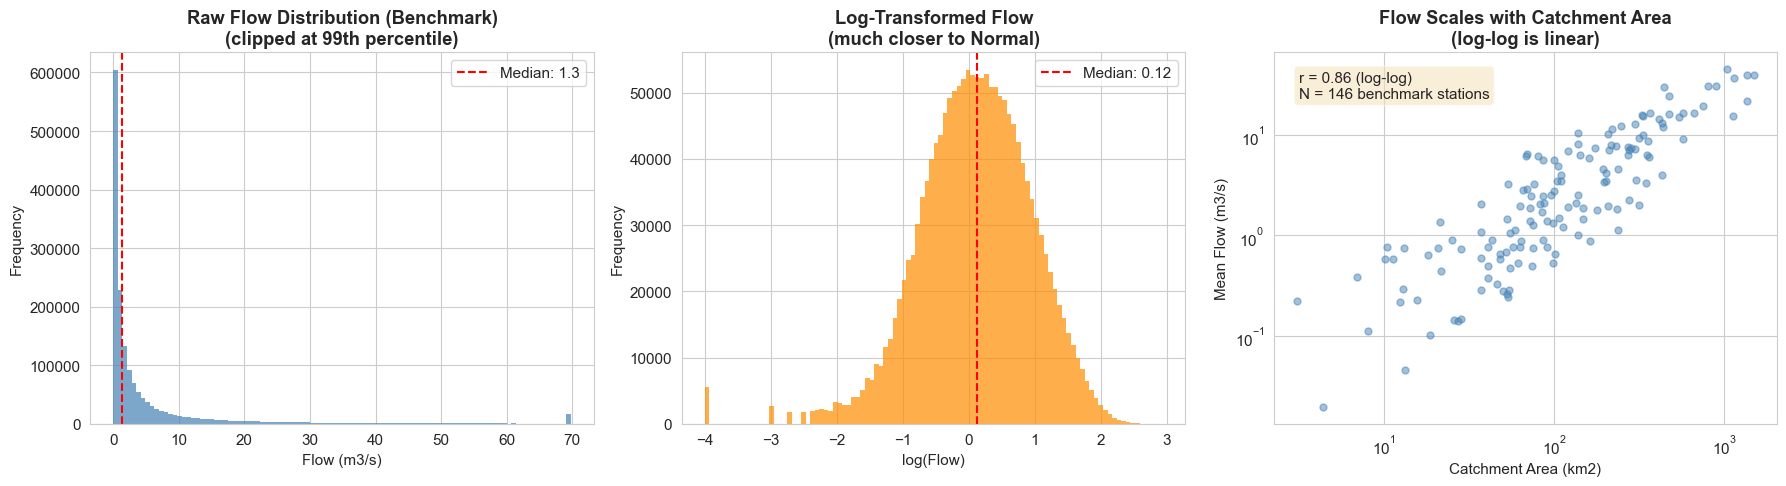

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

flow_valid = ts['flow'].dropna()
axes[0].hist(flow_valid.clip(upper=flow_valid.quantile(0.99)), bins=100,
             edgecolor='none', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Flow (m3/s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Flow Distribution (Benchmark)\n(clipped at 99th percentile)', fontweight='bold')
axes[0].axvline(flow_valid.median(), color='red', ls='--', label=f'Median: {flow_valid.median():.1f}')
axes[0].legend()

log_flow = np.log1p(flow_valid)
axes[1].hist(log_flow, bins=100, edgecolor='none', alpha=0.7, color='darkorange')
axes[1].set_xlabel('ln(1+Q)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('ln(1+Q) Transformed Flow\n(much closer to Normal)', fontweight='bold')
axes[1].axvline(log_flow.median(), color='red', ls='--', label=f'Median: {log_flow.median():.2f}')
axes[1].legend()

station_means = ts.groupby('station_id')['flow'].mean().reset_index()
station_means = station_means.merge(
    meta[['id', 'catchment-area']].rename(columns={'id': 'station_id', 'catchment-area': 'area'}),
    on='station_id', how='inner'
)
axes[2].scatter(station_means['area'], station_means['flow'], alpha=0.5, s=25, c='steelblue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Catchment Area (km2)')
axes[2].set_ylabel('Mean Flow (m3/s)')
axes[2].set_title('Flow Scales with Catchment Area\n(log-log is linear)', fontweight='bold')

valid = station_means.dropna()
r, p = stats.pearsonr(np.log10(valid['area']), np.log10(valid['flow']))
axes[2].text(0.05, 0.95, f'r = {r:.2f} (log-log)\nN = {len(valid)} benchmark stations',
             transform=axes[2].transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

- raw flow skewness of 8.30 so flood days dominate the tail. MSE on raw values would be a flood detector ignoring 99% of days. ln(1+Q) transform pulls this to -0.56, near-symmetric, making MSE sensible.
- area–flow r = 0.86 (log-log) is the known scaling law $\bar{Q} \propto A^\alpha$, a constraint: pooled models without area waste capacity re-learning it. feeding log(area) lets the model focus on geology and climate.
- 8.6 million-fold range across stations so we need per-station normalisation. a 1 m3/s error on the Thames is nothing; the same error on a highland burn exceeds its entire flow range.

---
the metadata has 109 descriptors. most must be redundant. rather than picking by intuition, correlate everything against flow characteristics and see what survives.

In [5]:
meta_renamed = meta.rename(columns={'id': 'station_id'})

descriptor_groups = {
    'Geology / Storage': ['bfihost19', 'bfihost19-scaled', 'gdf-base-flow-index',
                          'high-perm-bedrock', 'moderate-perm-bedrock', 'low-perm-bedrock',
                          'mixed-perm-bedrock', 'high-perm-superficial', 'low-perm-superficial',
                          'mixed-perm-superficial'],
    'Scale / Area': ['catchment-area', 'ihdtm-catchment-area'],
    'Climate / Rainfall': ['saar-1941-1970', 'saar-1961-1990', 'saar-1991-2020',
                           'rmed-1d', 'rmed-2d', 'rmed-1h'],
    'Topography': ['altbar', 'dpsbar', 'aspbar', 'aspvar',
                   'minimum-altitude', '10-percentile-altitude', '50-percentile-altitude',
                   '90-percentile-altitude', 'maximum-altitude', 'ihdtm-height'],
    'Wetness / Runoff': ['propwet', 'sprhost'],
    'Land Cover': ['lcm2007-woodland', 'lcm2007-arable-horticultural', 'lcm2007-grassland',
                   'lcm2007-mountain-heath-bog', 'lcm2007-urban'],
    'Urbanisation': ['urbext-1990', 'urbext-2000', 'urbext-2015',
                     'urbconc-1990', 'urbconc-2000', 'urbloc-1990', 'urbloc-2000'],
    'Drainage': ['draindens', 'ldp', 'dplbar'],
    'Lakes / Attenuation': ['farl', 'farl-2015'],
    'Flood Statistics': ['qmed', 'nrfa-mean-flow', 'nrfa-peak-flow',
                         'mean-flood-plain-depth', 'mean-flood-plain-extent'],
}

available_groups = {}
for group, cols in descriptor_groups.items():
    existing = [c for c in cols if c in meta_renamed.columns]
    if existing:
        available_groups[group] = existing

total = sum(len(v) for v in available_groups.values())
print(f'Categorised {total} descriptors into {len(available_groups)} physical groups:\n')
for group, cols in available_groups.items():
    print(f'  {group:30s} ({len(cols):2d}): {", ".join(cols[:4])}{"..." if len(cols) > 4 else ""}')

Categorised 52 descriptors into 10 physical groups:

  Geology / Storage              (10): bfihost19, bfihost19-scaled, gdf-base-flow-index, high-perm-bedrock...
  Scale / Area                   ( 2): catchment-area, ihdtm-catchment-area
  Climate / Rainfall             ( 6): saar-1941-1970, saar-1961-1990, saar-1991-2020, rmed-1d...
  Topography                     (10): altbar, dpsbar, aspbar, aspvar...
  Wetness / Runoff               ( 2): propwet, sprhost
  Land Cover                     ( 5): lcm2007-woodland, lcm2007-arable-horticultural, lcm2007-grassland, lcm2007-mountain-heath-bog...
  Urbanisation                   ( 7): urbext-1990, urbext-2000, urbext-2015, urbconc-1990...
  Drainage                       ( 3): draindens, ldp, dplbar
  Lakes / Attenuation            ( 2): farl, farl-2015
  Flood Statistics               ( 5): qmed, nrfa-mean-flow, nrfa-peak-flow, mean-flood-plain-depth...


In [6]:
train_stats = train.groupby('station_id').agg(
    mean_flow=('flow', 'mean'),
    std_flow=('flow', 'std'),
    cv_flow=('flow', lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan),
    skew_flow=('flow', 'skew'),
    q90_flow=('flow', lambda x: x.quantile(0.9)),
    q10_flow=('flow', lambda x: x.quantile(0.1)),
).reset_index()

flashiness = train.sort_values(['station_id', 'date']).groupby('station_id')['flow'].apply(
    lambda x: x.diff().abs().mean() / x.mean() if x.mean() > 0 else np.nan
).reset_index().rename(columns={'flow': 'flashiness'})

train_stats = train_stats.merge(flashiness, on='station_id')

train_stats['q90_q10_ratio'] = train_stats['q90_flow'] / train_stats['q10_flow'].clip(lower=0.001)

station_data = train_stats.merge(meta_renamed, on='station_id', how='inner')

flow_metrics = ['cv_flow', 'flashiness', 'skew_flow', 'q90_q10_ratio', 'mean_flow']
all_descriptors = [c for group in available_groups.values() for c in group]

corr_matrix_all = []
for col in all_descriptors:
    if col not in station_data.columns:
        continue
    row = {'descriptor': col}
    for metric in flow_metrics:
        valid = station_data[[metric, col]].dropna()
        if len(valid) > 30:
            r, p = stats.spearmanr(valid[metric], valid[col])
            row[f'r_{metric}'] = r
            row[f'p_{metric}'] = p
        else:
            row[f'r_{metric}'] = np.nan
            row[f'p_{metric}'] = np.nan
    corr_matrix_all.append(row)

corr_all = pd.DataFrame(corr_matrix_all)

r_cols = [f'r_{m}' for m in flow_metrics]
corr_all['max_abs_r'] = corr_all[r_cols].abs().max(axis=1)
corr_all = corr_all.sort_values('max_abs_r', ascending=False)

/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3462823563.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(valid[metric], valid[col])
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3462823563.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(valid[metric], valid[col])
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3462823563.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(valid[metric], valid[col])
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3462823563.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(valid[metric], valid[col])
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3462823563.py:36: C

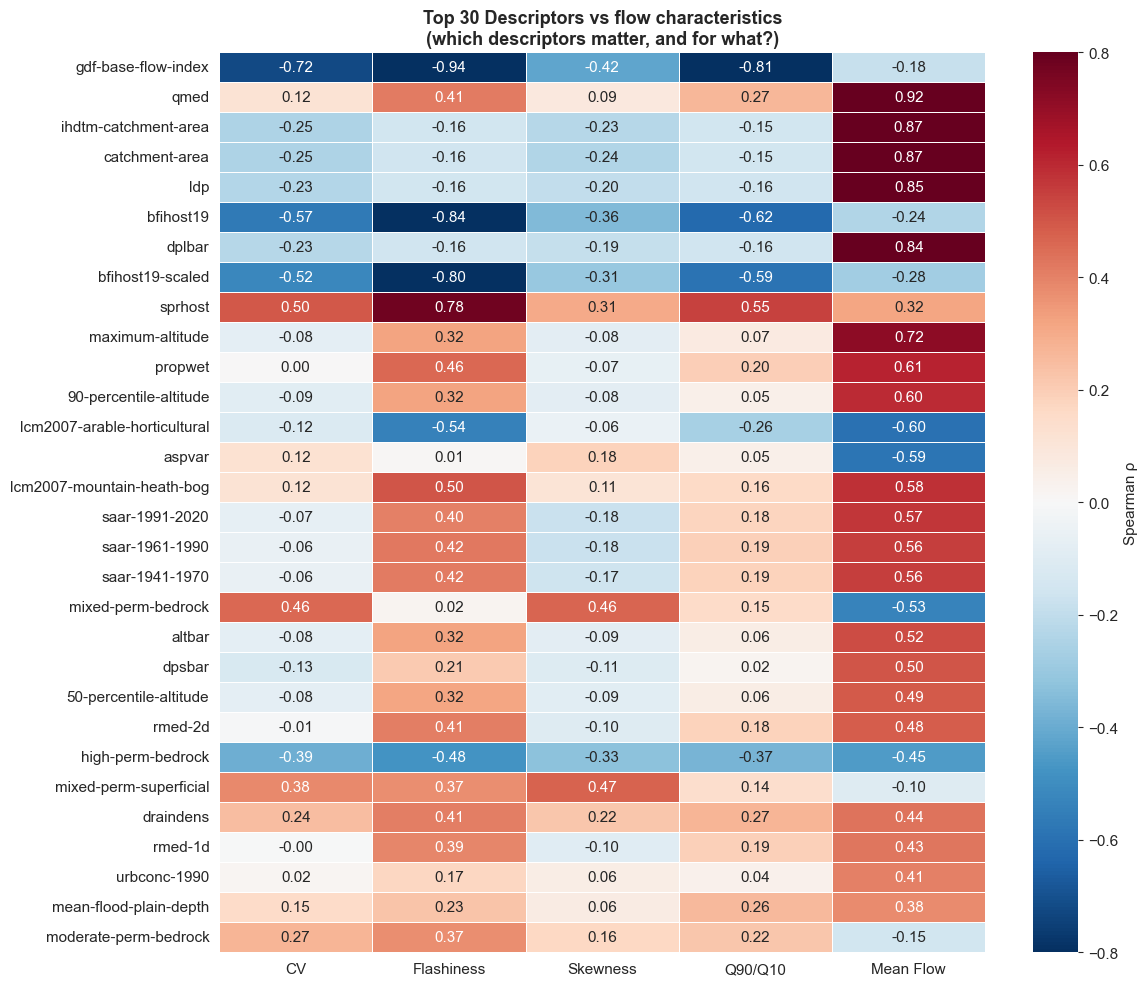

In [7]:
top30 = corr_all.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
heatmap_data = top30.set_index('descriptor')[r_cols]
heatmap_data.columns = ['CV', 'Flashiness', 'Skewness', 'Q90/Q10', 'Mean Flow']

sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, vmin=-0.8, vmax=0.8,
            annot=True, fmt='.2f', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Top 30 Descriptors vs flow characteristics\n(which descriptors matter, and for what?)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

- descriptors split into two families: those predicting how variable flow is (CV, flashiness) and those predicting how much (mean flow). almost nothing does both.
- geology (BFI, gdf-base-flow-index, sprhost) dominates the variability columns but is blank against mean flow, it tells you how the catchment behaves, not how much water.
- scale (area, qmed, ldp) does the reverse. high volume from collecting more rain, but spatial averaging damps storm response.
- gdf-base-flow-index at |r| = 0.94 against flashiness is near-deterministic. if u know the BFI, u know the flashiness.
- climate (SAAR, propwet) sits between both families, and so wetter catchments have more flow and more saturated soils generating faster runoff. dual role makes SAAR an efficient feature.

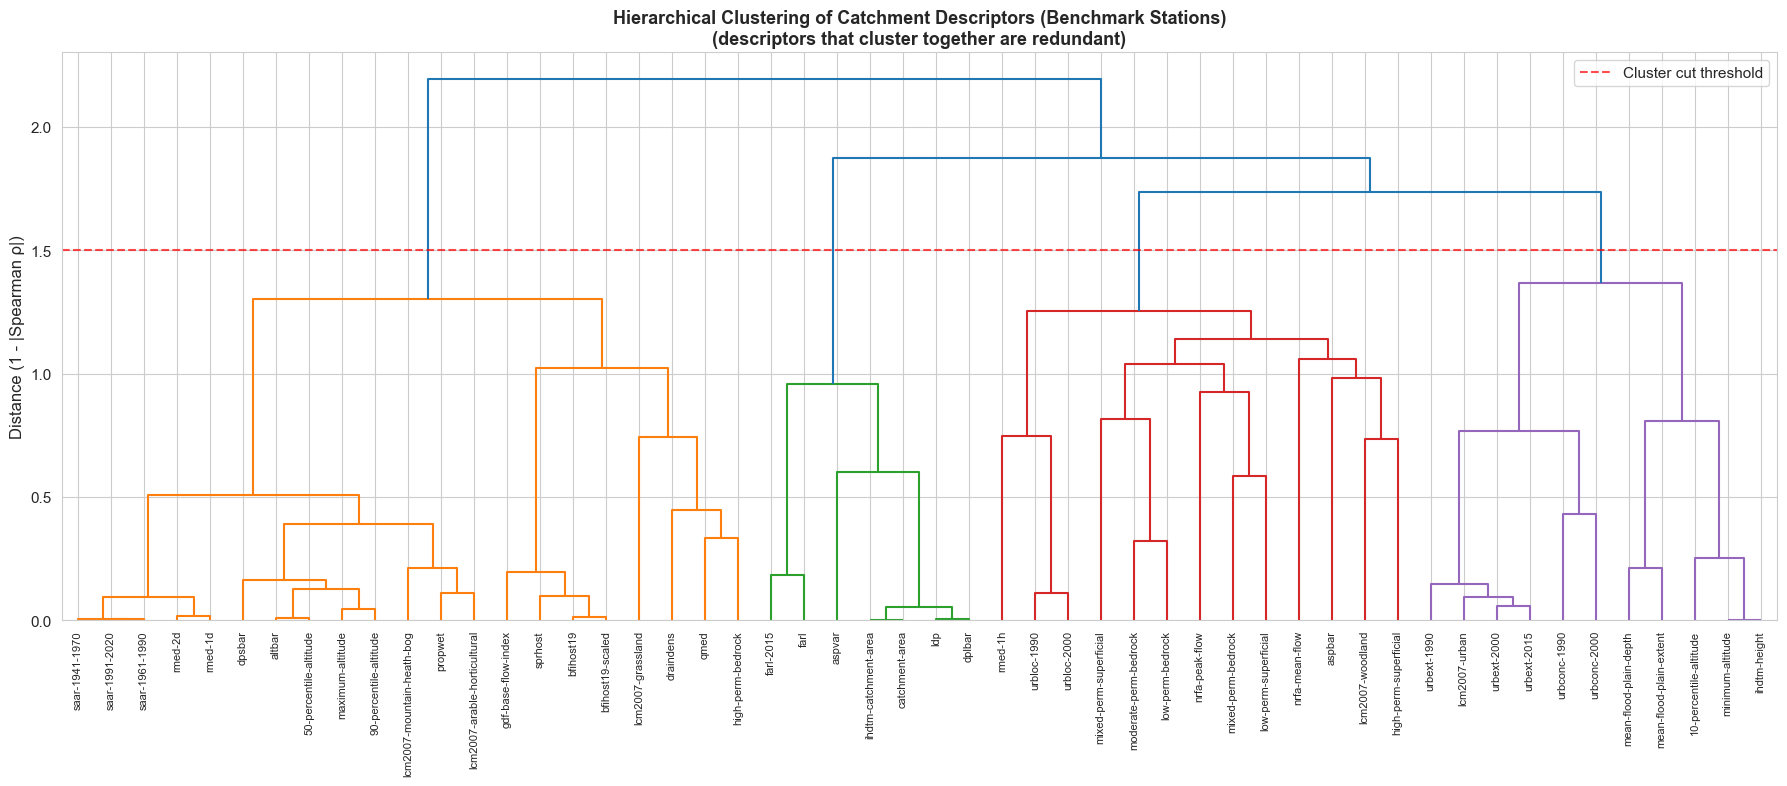


8 descriptor clusters identified:

Cluster 1 (13 members):
  Best: maximum-altitude (max |r| = 0.716)
  Others: propwet, 90-percentile-altitude, lcm2007-arable-horticultural, lcm2007-mountain-heath-bog

Cluster 2 (8 members):
  Best: gdf-base-flow-index (max |r| = 0.941)
  Others: qmed, bfihost19, bfihost19-scaled, sprhost

Cluster 3 (7 members):
  Best: ihdtm-catchment-area (max |r| = 0.873)
  Others: catchment-area, ldp, dplbar, aspvar

Cluster 4 (3 members):
  Best: urbloc-1990 (max |r| = 0.293)
  Others: rmed-1h, urbloc-2000

Cluster 5 (6 members):
  Best: mixed-perm-bedrock (max |r| = 0.534)
  Others: mixed-perm-superficial, moderate-perm-bedrock, low-perm-superficial, nrfa-peak-flow

Cluster 6 (4 members):
  Best: lcm2007-woodland (max |r| = 0.189)
  Others: high-perm-superficial, aspbar, nrfa-mean-flow

Cluster 7 (6 members):
  Best: urbconc-1990 (max |r| = 0.405)
  Others: urbext-1990, urbext-2000, urbconc-2000, urbext-2015

Cluster 8 (5 members):
  Best: mean-flood-plain-dept

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

desc_cols = [c for c in corr_all['descriptor'].tolist() if c in station_data.columns]
desc_data = station_data[desc_cols].dropna(axis=1, how='all')
desc_corr = desc_data.corr(method='spearman')

dist_matrix = (1 - desc_corr.abs()).values.copy()
np.fill_diagonal(dist_matrix, 0)
dist_matrix = np.nan_to_num(dist_matrix, nan=1.0)  # NaN → max distance
dist_condensed = squareform(dist_matrix, checks=False)

linkage_matrix = linkage(dist_condensed, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
dendro = dendrogram(linkage_matrix, labels=desc_corr.columns.tolist(),
                    leaf_rotation=90, leaf_font_size=8, ax=ax,
                    color_threshold=1.5)
ax.set_title('Hierarchical Clustering of Catchment Descriptors (Benchmark Stations)\n'
             '(descriptors that cluster together are redundant)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Distance (1 - |Spearman ρ|)', fontsize=12)
ax.axhline(1.5, color='red', ls='--', alpha=0.7, label='Cluster cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

n_clusters = 8
clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
desc_clusters = pd.DataFrame({'descriptor': desc_corr.columns, 'cluster': clusters})
desc_clusters = desc_clusters.merge(corr_all[['descriptor', 'max_abs_r']], on='descriptor', how='left')

print(f'\n{n_clusters} descriptor clusters identified:\n')
for cl in sorted(desc_clusters['cluster'].unique()):
    members = desc_clusters[desc_clusters['cluster'] == cl].sort_values('max_abs_r', ascending=False)
    best = members.iloc[0]
    print(f'Cluster {cl} ({len(members)} members):')
    print(f'  Best: {best["descriptor"]} (max |r| = {best["max_abs_r"]:.3f})')
    print(f'  Others: {", ".join(members["descriptor"].values[1:5])}')
    print()

- 52 descriptors collapse into about 8 clusters. much of the metadata says the same thing in different ways.
- gdf-base-flow-index and bfihost19 cluster together despite independent sources like GDF-BFI from observed flow records, bfihost19 from HOST soil/geology maps. cross-validates BFI as a real physical quantity, not some arbitrary statistic.
- area cluster (area, ihdtm-area, ldp, dplbar) is pure geometric scale. keeping `catchment-area` alone discards nothing.
- the upland cluster groups altitude, propwet, and moorland land cover. UK geography where high, wet, and peaty co-occur along the NW–SE gradient of Atlantic exposure.

In [9]:
selected = []
for cl in sorted(desc_clusters['cluster'].unique()):
    members = desc_clusters[desc_clusters['cluster'] == cl].sort_values('max_abs_r', ascending=False)
    
    for _, row in members.iterrows():
        desc = row['descriptor']
        if desc in station_data.columns:
            coverage = station_data[desc].notna().mean()
            if coverage > 0.8:
                selected.append({
                    'cluster': cl,
                    'descriptor': desc,
                    'max_abs_r': row['max_abs_r'],
                    'coverage': coverage,
                    'cluster_size': len(members),
                    'alternatives': ', '.join(members['descriptor'].values[1:3])
                })
                break

selected_df = pd.DataFrame(selected).sort_values('max_abs_r', ascending=False)

print(selected_df.to_string(index=False, float_format='{:.3f}'.format))
print(f'\n{len(selected_df)} candidate features from {len(desc_clusters["cluster"].unique())} clusters')

 cluster             descriptor  max_abs_r  coverage  cluster_size                                  alternatives
       2    gdf-base-flow-index      0.941     1.000             8                               qmed, bfihost19
       3   ihdtm-catchment-area      0.873     1.000             7                           catchment-area, ldp
       1       maximum-altitude      0.716     1.000            13               propwet, 90-percentile-altitude
       5 mixed-perm-superficial      0.470     0.842             6 mixed-perm-superficial, moderate-perm-bedrock
       8 mean-flood-plain-depth      0.381     1.000             5      10-percentile-altitude, minimum-altitude
       7            urbext-1990      0.344     1.000             6                      urbext-1990, urbext-2000
       4                rmed-1h      0.255     1.000             3                          rmed-1h, urbloc-2000
       6       lcm2007-woodland      0.189     0.986             4                 high-perm-sup

### wrapping up the static descriptors

- we end up on three features: **BFI** (geology/storage, controls variability), **area** (scale, controls magnitude), **SAAR** (climate, controls wetness). three physical processes from three clusters — non-redundant by construction.
- additional descriptors (propwet, dpsbar, urbext) add marginally but are partially collinear with these three.

## spatial distribution of benchmark stations

before looking at temporal structure, check where these 146 stations actually sit. UK hydrology is dominated by the NW–SE gradient: Atlantic-exposed, wet, upland, flashy in the west; sheltered, dry, lowland, baseflow-dominated in the east. if that gradient shows up in the station map, it confirms BFI and SAAR capture real geography.</cell id="cell-13">
<parameter name="cell_type">markdown

/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3842244814.py:39: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/3842244814.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/Documents/deep-learning-exp/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aayush/Documents/deep-learning-exp/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


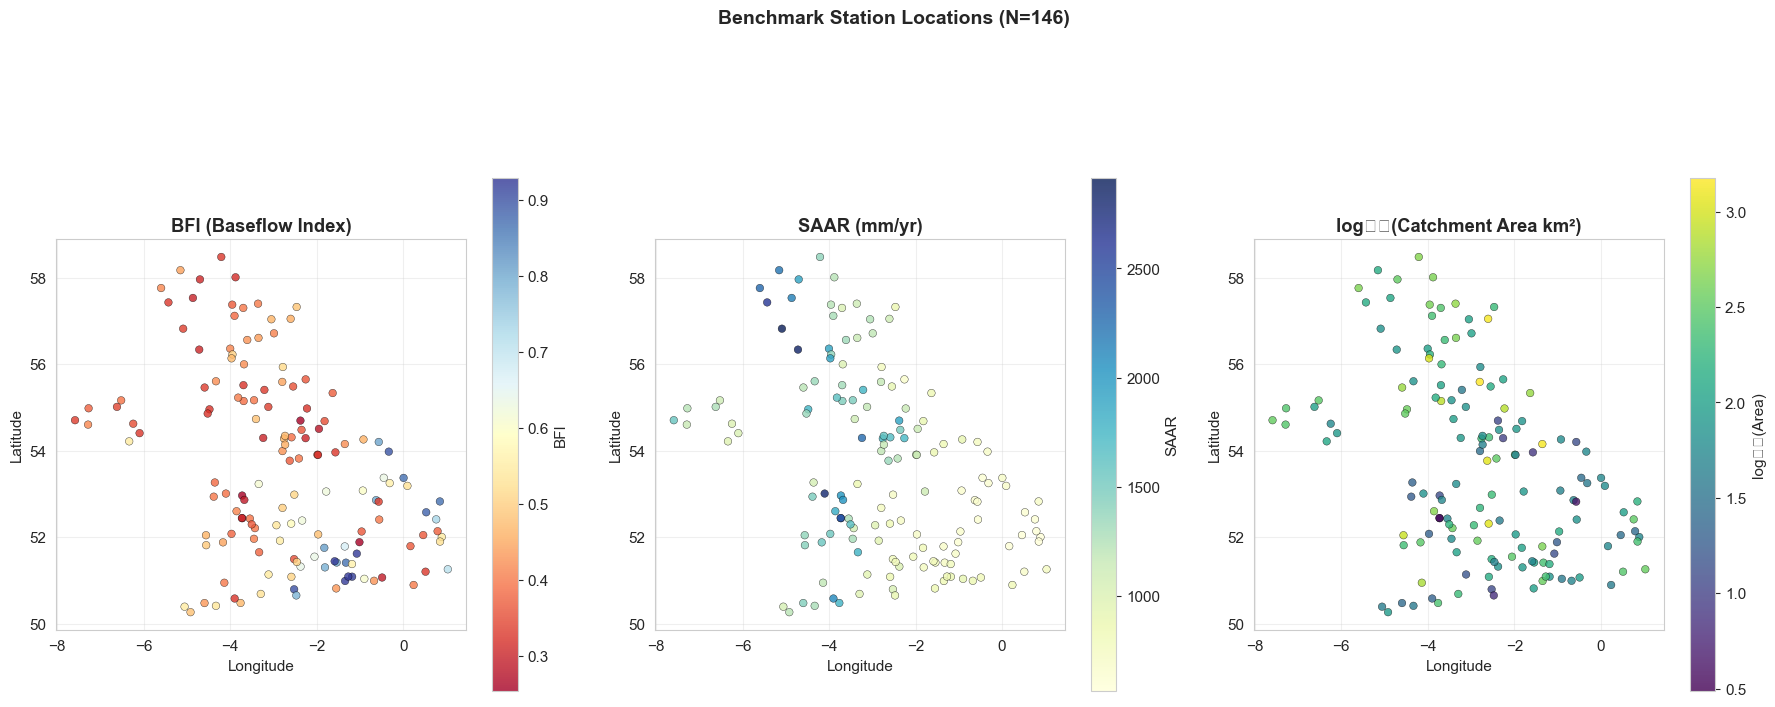

Spatial gradients (Spearman with longitude):
  BFI  vs longitude: r = +0.38  (east = more baseflow)
  SAAR vs longitude: r = -0.77  (west = wetter)


In [10]:
meta_map = meta[['id', 'latitude', 'longitude', 'bfihost19', 'catchment-area',
                  'saar-1961-1990']].rename(columns={
    'id': 'station_id', 'bfihost19': 'bfi',
    'catchment-area': 'area', 'saar-1961-1990': 'saar'
}).dropna(subset=['latitude', 'longitude'])

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sc1 = axes[0].scatter(meta_map['longitude'], meta_map['latitude'],
                       c=meta_map['bfi'], cmap='RdYlBu', s=30,
                       edgecolors='black', linewidth=0.3, alpha=0.8)
axes[0].set_title('BFI (Baseflow Index)', fontweight='bold')
plt.colorbar(sc1, ax=axes[0], shrink=0.7, label='BFI')

sc2 = axes[1].scatter(meta_map['longitude'], meta_map['latitude'],
                       c=meta_map['saar'], cmap='YlGnBu', s=30,
                       edgecolors='black', linewidth=0.3, alpha=0.8)
axes[1].set_title('SAAR (mm/yr)', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], shrink=0.7, label='SAAR')

sc3 = axes[2].scatter(meta_map['longitude'], meta_map['latitude'],
                       c=np.log10(meta_map['area'].clip(lower=1)),
                       cmap='viridis', s=30,
                       edgecolors='black', linewidth=0.3, alpha=0.8)
axes[2].set_title('log₁₀(Catchment Area km²)', fontweight='bold')
plt.colorbar(sc3, ax=axes[2], shrink=0.7, label='log₁₀(Area)')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.suptitle('Benchmark Station Locations (N=146)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
r_bfi_lon, _ = spearmanr(meta_map['longitude'], meta_map['bfi'])
r_saar_lon, _ = spearmanr(meta_map['longitude'], meta_map['saar'])
print(f'Spatial gradients (Spearman with longitude):')
print(f'  BFI  vs longitude: r = {r_bfi_lon:+.2f}  (east = more baseflow)')
print(f'  SAAR vs longitude: r = {r_saar_lon:+.2f}  (west = wetter)')

In [11]:
meta_bfi = meta[['id', 'bfihost19']].rename(columns={'id': 'station_id', 'bfihost19': 'bfi'}).dropna()

low_bfi = meta_bfi.nsmallest(5, 'bfi')['station_id'].tolist()   # Flashiest benchmark stations
high_bfi = meta_bfi.nlargest(5, 'bfi')['station_id'].tolist()   # Most stable benchmark stations
mid_bfi = meta_bfi.iloc[(meta_bfi['bfi'] - 0.5).abs().argsort()[:5]]['station_id'].tolist()

representative = {
    'Low BFI (Flashy)': low_bfi,
    'Mid BFI': mid_bfi,
    'High BFI (Stable)': high_bfi
}

for group, sids in representative.items():
    bfis = meta_bfi[meta_bfi['station_id'].isin(sids)]['bfi'].values
    print(f'  {group}: BFI = {bfis.mean():.2f} ({len(sids)} stations)')

  Low BFI (Flashy): BFI = 0.27 (5 stations)
  Mid BFI: BFI = 0.50 (5 stations)
  High BFI (Stable): BFI = 0.92 (5 stations)


/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/2281511439.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, col_idx].legend(fontsize=9)
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/2281511439.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, col_idx].legend(fontsize=9)
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/2281511439.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, col_idx].legend(fontsize=9)
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/2281511439.py:42: UserWarning: No artists with labels found to

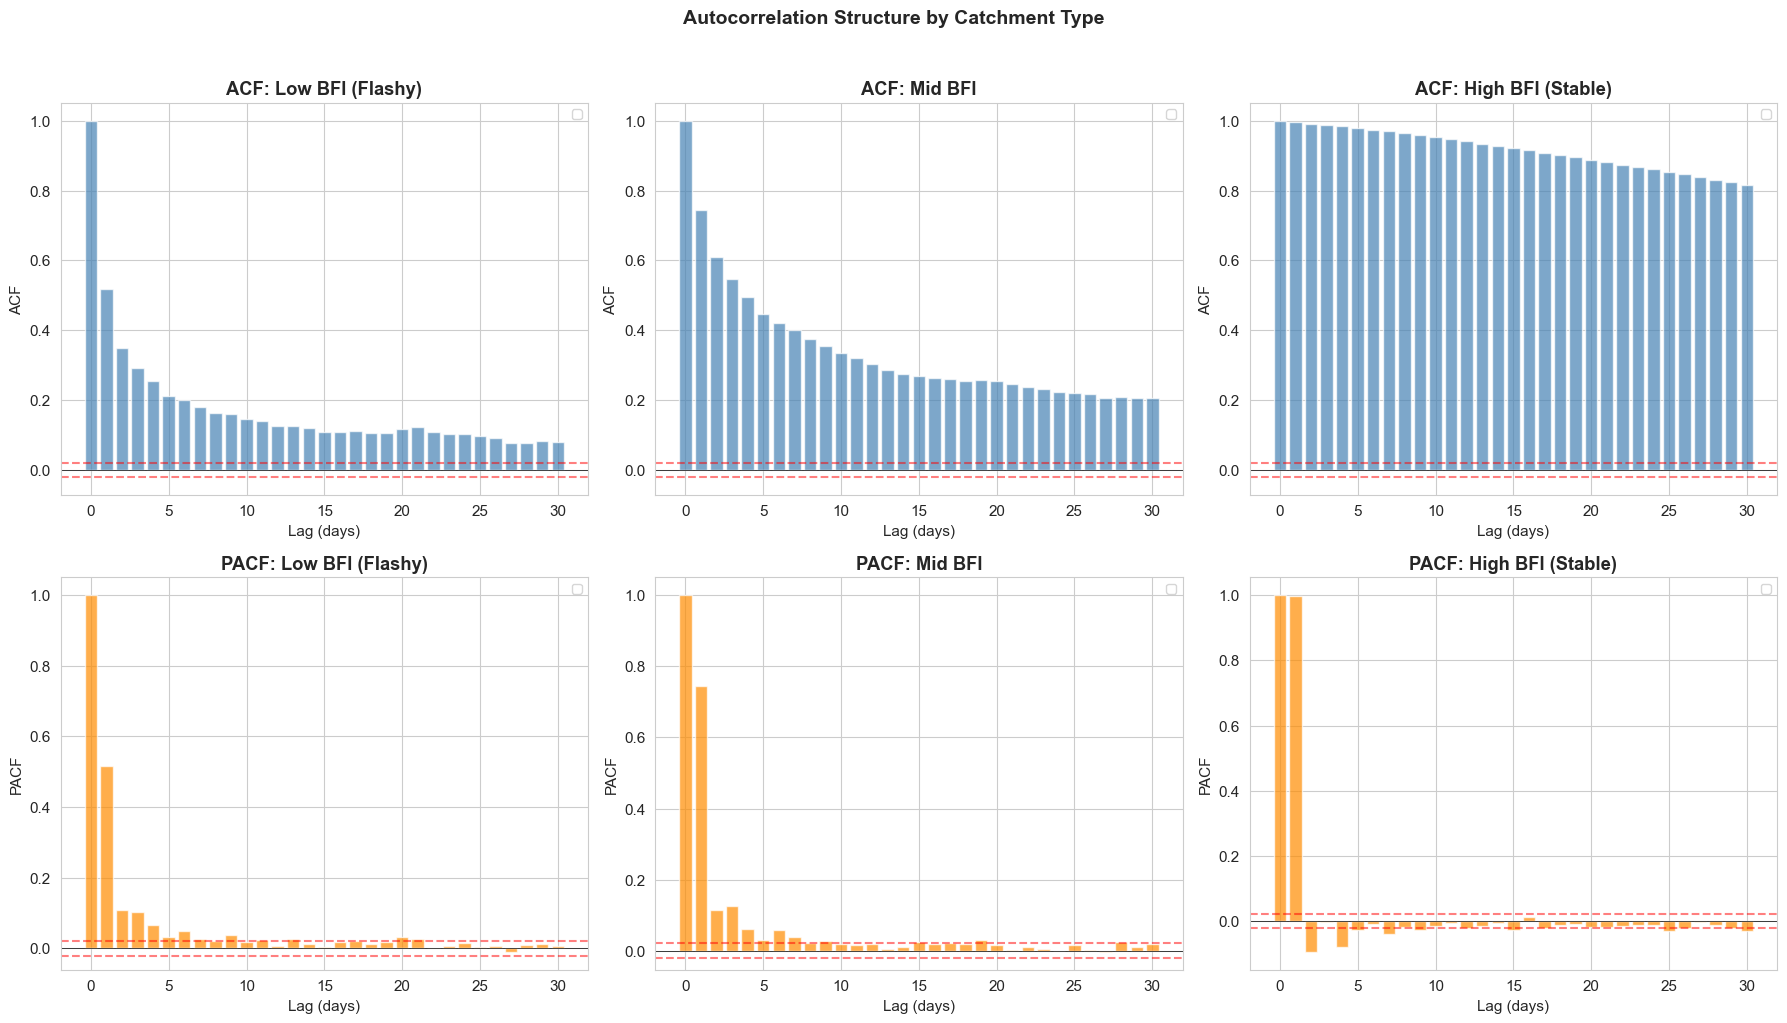

In [12]:
max_lag = 30

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (group, sids) in enumerate(representative.items()):
    acf_all = []
    pacf_all = []
    
    for sid in sids:
        station_flow = train[train['station_id'] == sid]['flow'].dropna().values
        if len(station_flow) > max_lag * 3:
            acf_vals = acf(station_flow, nlags=max_lag, fft=True)
            pacf_vals = pacf(station_flow, nlags=max_lag)
            acf_all.append(acf_vals)
            pacf_all.append(pacf_vals)
    
    if not acf_all:
        continue
    
    acf_mean = np.mean(acf_all, axis=0)
    pacf_mean = np.mean(pacf_all, axis=0)
    
    axes[0, col_idx].bar(range(max_lag + 1), acf_mean, color='steelblue', alpha=0.7, width=0.8)
    axes[0, col_idx].axhline(0, color='black', linewidth=0.5)
    axes[0, col_idx].axhline(1.96 / np.sqrt(len(station_flow)), color='red', ls='--', alpha=0.5)
    axes[0, col_idx].axhline(-1.96 / np.sqrt(len(station_flow)), color='red', ls='--', alpha=0.5)
    axes[0, col_idx].set_xlabel('Lag (days)')
    axes[0, col_idx].set_ylabel('ACF')
    axes[0, col_idx].set_title(f'ACF: {group}', fontweight='bold')
    axes[0, col_idx].legend(fontsize=9)
    
    axes[1, col_idx].bar(range(max_lag + 1), pacf_mean, color='darkorange', alpha=0.7, width=0.8)
    axes[1, col_idx].axhline(0, color='black', linewidth=0.5)
    axes[1, col_idx].axhline(1.96 / np.sqrt(len(station_flow)), color='red', ls='--', alpha=0.5)
    axes[1, col_idx].axhline(-1.96 / np.sqrt(len(station_flow)), color='red', ls='--', alpha=0.5)
    axes[1, col_idx].set_xlabel('Lag (days)')
    axes[1, col_idx].set_ylabel('PACF')
    axes[1, col_idx].set_title(f'PACF: {group}', fontweight='bold')
    axes[1, col_idx].legend(fontsize=9)

plt.suptitle('Autocorrelation Structure by Catchment Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- acf: total corr at each lag including indirect effects
- pacf: direct corr at each lag after removing shorter lags
- high bfi stations: acf decays slowly so long memory (groundwater river)
- low bfi: acf decays fast so short memory (surface runoff rivers)

- low BFI (clay, urban): ACF drops below significance within ~5 days. only lag 1–2 carry direct predictive power. rain hits impermeable surfaces, runs off in hours, catchment resets. AR model here is essentially $Q_{t+1} \approx \phi Q_t$ plus noise, whhere noise is the rainfall the model cannot see.
- high BFI (chalk, limestone): ACF above 0.5 past lag 20. weeks of rainfall stored in the aquifer. PACF shows slight negative values at lags 2–5 — mean reversion. after accounting for yesterday's flow, the day before predicts slightly *lower* flow. aquifer as natural damper: high water table → accelerated drainage → equilibrium.
- modelling implication: autoregression should excel on high-BFI (smooth, mean-reverting) and fail on low-BFI (unpredictable without rainfall).

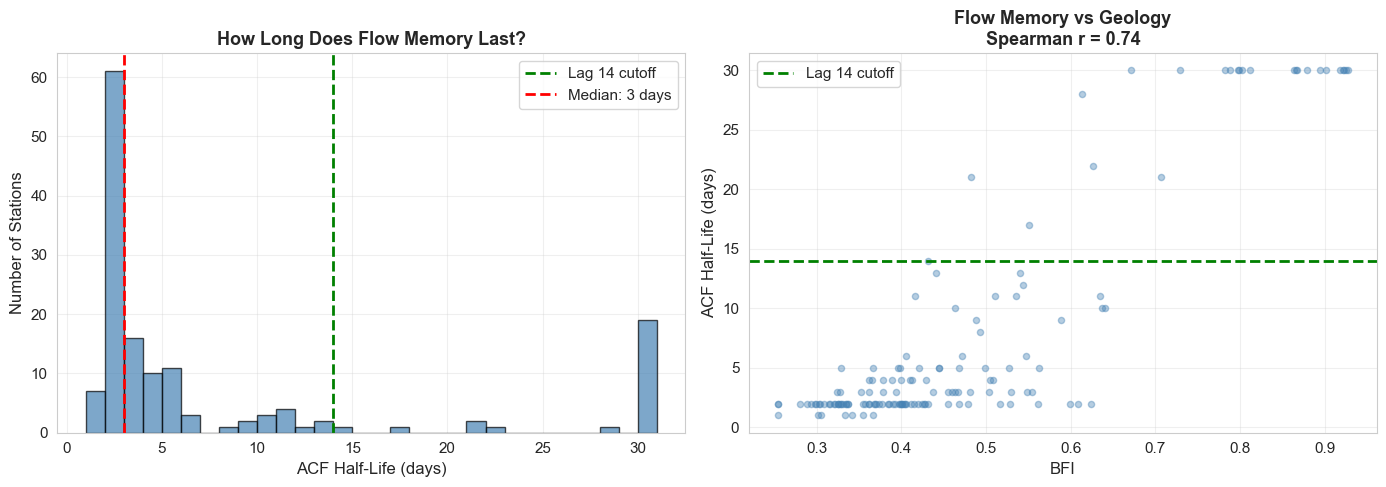

In [13]:
half_life_lags = []

for sid in train['station_id'].unique():
    station_flow = train[train['station_id'] == sid]['flow'].dropna().values
    if len(station_flow) < 100:
        continue
    acf_vals = acf(station_flow, nlags=30, fft=True)
    below_half = np.where(acf_vals[1:] < 0.5)[0]
    hl = below_half[0] + 1 if len(below_half) > 0 else 30
    half_life_lags.append({'station_id': sid, 'acf_half_life': hl})

hl_df = pd.DataFrame(half_life_lags)
hl_df = hl_df.merge(meta_bfi, on='station_id', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hl_df['acf_half_life'], bins=range(1, 32), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(14, color='green', ls='--', lw=2, label='Lag 14 cutoff')
axes[0].axvline(hl_df['acf_half_life'].median(), color='red', ls='--', lw=2, 
               label=f'Median: {hl_df["acf_half_life"].median():.0f} days')
axes[0].set_xlabel('ACF Half-Life (days)', fontsize=12)
axes[0].set_ylabel('Number of Stations', fontsize=12)
axes[0].set_title('How Long Does Flow Memory Last?', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(hl_df['bfi'], hl_df['acf_half_life'], alpha=0.4, s=20, c='steelblue')
axes[1].axhline(14, color='green', ls='--', lw=2, label='Lag 14 cutoff')
r, p = stats.spearmanr(hl_df['bfi'], hl_df['acf_half_life'])
axes[1].set_xlabel('BFI', fontsize=12)
axes[1].set_ylabel('ACF Half-Life (days)', fontsize=12)
axes[1].set_title(f'Flow Memory vs Geology\nSpearman r = {r:.2f}', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pct_covered = (hl_df['acf_half_life'] <= 14).mean() * 100

In [14]:
print(f'\nLag 14 covers {pct_covered:.0f}% of stations (ACF half-life <= 14 days)')
print(f'Remaining {100-pct_covered:.0f}% are high-BFI groundwater stations with very long memory')
print(f'\nBFI-memory correlation: r = {r:.2f} and so geology controls flow persistence')


Lag 14 covers 84% of stations (ACF half-life <= 14 days)
Remaining 16% are high-BFI groundwater stations with very long memory

BFI-memory correlation: r = 0.74 and so geology controls flow persistence


- ACF half-life distribution is bimodal: cluster at 2–5 days (flashy) and a tail past 20 days (groundwater). lag-14 captures 84% of stations; the remaining 16% are high-BFI chalk/limestone.
- for those long-memory stations, rolling-window features (7d, 14d means) compress longer-range information. the LSTM handles this more naturally — cell state maintains memory over arbitrary horizons without explicit lags.
- BFI–memory correlation: spearman r = 0.74. bfi from soil maps, acf half-life from flow timeseries are two independent data sources confirming the same physics. UK river memory is governed by subsurface geology.

## rainfall–flow cross-correlation

flow autocorrelation is about the river's memory. rainfall is the driver. the cross correlation function shows each catchment's impulse response, specifically how a single day of rain propagates through the system.

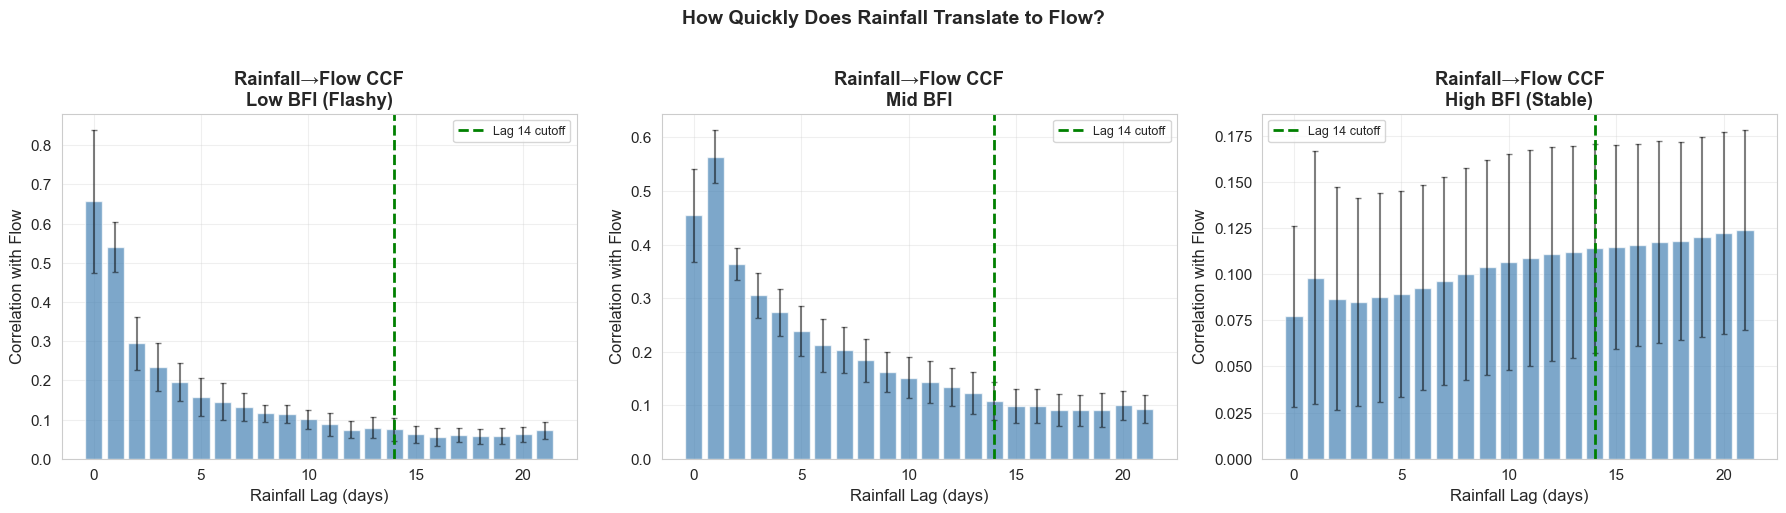

In [15]:
max_lag = 21

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, (group, sids) in enumerate(representative.items()):
    ccf_all = []
    
    for sid in sids:
        sdata = train[train['station_id'] == sid][['flow', 'rainfall']].dropna()
        if len(sdata) < 365:
            continue
        
        ccf_vals = []
        for lag in range(max_lag + 1):
            if lag == 0:
                r = sdata['rainfall'].corr(sdata['flow'])
            else:
                r = sdata['rainfall'].shift(lag).corr(sdata['flow'])
            ccf_vals.append(r)
        ccf_all.append(ccf_vals)
    
    if not ccf_all:
        continue
    
    ccf_mean = np.mean(ccf_all, axis=0)
    ccf_std = np.std(ccf_all, axis=0)
    
    axes[col_idx].bar(range(max_lag + 1), ccf_mean, color='steelblue', alpha=0.7, width=0.8)
    axes[col_idx].errorbar(range(max_lag + 1), ccf_mean, yerr=ccf_std, 
                          fmt='none', color='black', capsize=2, alpha=0.5)
    axes[col_idx].axvline(14, color='green', ls='--', lw=2, label='Lag 14 cutoff')
    axes[col_idx].set_xlabel('Rainfall Lag (days)', fontsize=12)
    axes[col_idx].set_ylabel('Correlation with Flow', fontsize=12)
    axes[col_idx].set_title(f'Rainfall→Flow CCF\n{group}', fontweight='bold')
    axes[col_idx].legend(fontsize=9)
    axes[col_idx].grid(alpha=0.3)

plt.suptitle('How Quickly Does Rainfall Translate to Flow?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
print('Low BFI: Rainfall peak at lag 0-1 → fast surface runoff')
print('High BFI: Rainfall peak spread across lags 1-10+ imply slow filtration through groundwater')
print('\nThis justifies including rainfall lag 1 through 14')

Low BFI: Rainfall peak at lag 0-1 → fast surface runoff
High BFI: Rainfall peak spread across lags 1-10+ imply slow filtration through groundwater

This justifies including rainfall lag 1 through 14


- **low BFI:** sharp spike at lag 0–1, gone in two days. rain becomes flow immediately. tight error bars — consistent across flashy catchments.
- **high BFI:** broad peak at lag 3–5, correlation persisting past lag 14. rainfall percolates through chalk over days to weeks. wider error bars — fractured limestone drains faster than deep chalk, so "high BFI" is not monolithic.
- a linear model with rainfall lags can approximate the high-BFI response (smooth convolution kernel). but low-BFI is non-linear — same rainfall on dry vs. saturated soil produces completely different runoff. consider an LSTM for its implicit state tracking

## seasonality

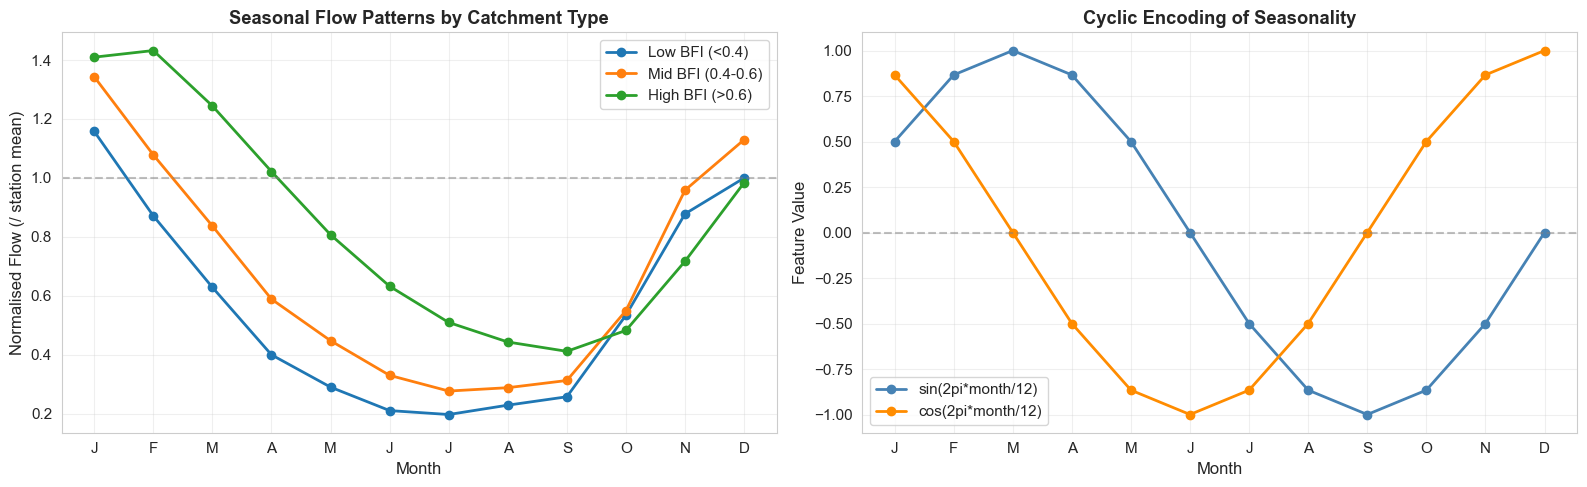

In [17]:
train_season = train[['station_id', 'date', 'flow', 'bfi']].copy()
train_season['month'] = train_season['date'].dt.month

train_season['bfi_group'] = pd.cut(train_season['bfi'],
                                    bins=[0, 0.4, 0.6, 1.0],
                                    labels=['Low BFI (<0.4)', 'Mid BFI (0.4-0.6)', 'High BFI (>0.6)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

station_means_train = train.groupby('station_id')['flow'].mean()
train_season['flow_norm'] = train_season['station_id'].map(station_means_train)
train_season['flow_norm'] = train_season['flow'] / train_season['flow_norm']

monthly = train_season.dropna(subset=['bfi_group']).groupby(
    ['month', 'bfi_group'])['flow_norm'].median().reset_index()

for group in monthly['bfi_group'].dropna().unique():
    grp = monthly[monthly['bfi_group'] == group]
    axes[0].plot(grp['month'], grp['flow_norm'], 'o-', linewidth=2, markersize=6, label=group)

axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Normalised Flow (/ station mean)', fontsize=12)
axes[0].set_title('Seasonal Flow Patterns by Catchment Type', fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[0].legend()
axes[0].axhline(1, color='grey', ls='--', alpha=0.5)
axes[0].grid(alpha=0.3)

months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)

axes[1].plot(months, sin_vals, 'o-', linewidth=2, label='sin(2pi*month/12)', color='steelblue')
axes[1].plot(months, cos_vals, 'o-', linewidth=2, label='cos(2pi*month/12)', color='darkorange')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Feature Value', fontsize=12)
axes[1].set_title('Cyclic Encoding of Seasonality', fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[1].legend()
axes[1].axhline(0, color='grey', ls='--', alpha=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- BFI modulates the *amplitude* of the seasonal cycle. low-BFI swings ~3.6:1 summer-to-winter. high-BFI closer to 2:1.
- mechanism is evapotranspiration: on impermeable clay, once rain stops, flow drops sharply. on chalk, the aquifer sits below the root zone and sustains baseflow through the driest months.
- sin/cos encoding maps the circular calendar onto 2D where dec 31 and jan 1 are neighbours. two features suffice — the UK seasonal cycle is dominated by the first harmonic.

### STL decomposition: quantifying the seasonal vs residual split

the monthly climatology above shows *what* the seasonal pattern looks like. STL (Seasonal-Trend decomposition using Loess) formalises this by splitting each station's flow into three additive components: **trend** (long-term drift), **seasonal** (repeating annual cycle), and **residual** (everything else — weather events, antecedent conditions, the part models must actually learn).

this frames the modelling problem: if seasonality explains most variance, `month_sin/cos` is sufficient and simple models win. if the residual dominates, the model needs to learn event-scale dynamics — favouring LSTM over Ridge.

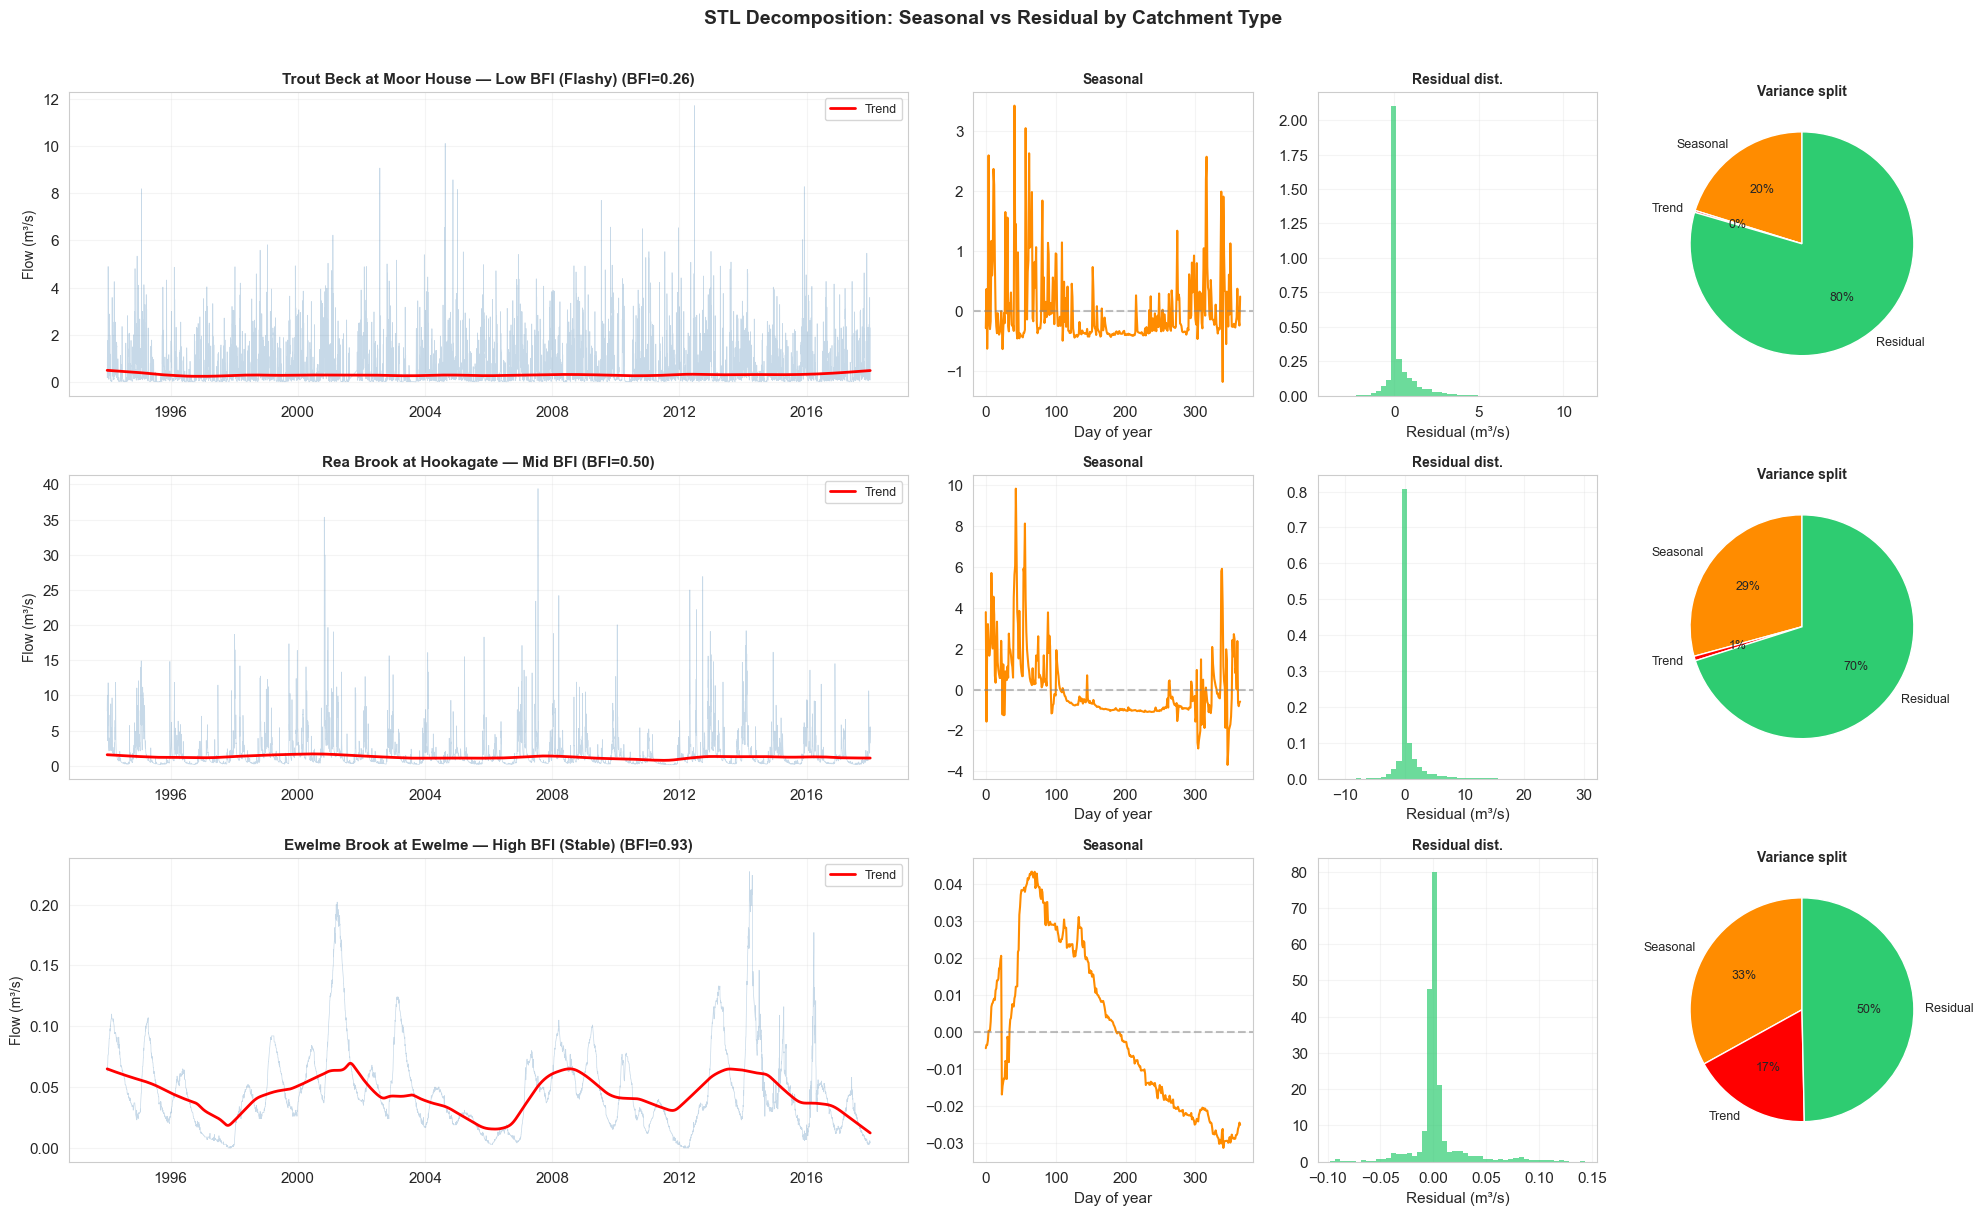

Variance decomposition (% of total):
            group                  station  bfi  seasonal_%  trend_%  residual_%
 Low BFI (Flashy) Trout Beck at Moor House  0.3        22.6      0.3        88.9
          Mid BFI   Rea Brook at Hookagate  0.5        30.9      0.7        74.1
High BFI (Stable)   Ewelme Brook at Ewelme  0.9        31.4     16.5        47.3


In [18]:
from statsmodels.tsa.seasonal import STL

stl_stations = {}
for group, sids in representative.items():
    for sid in sids:
        sdata = train[train['station_id'] == sid].set_index('date')['flow'].sort_index()
        if sdata.isna().mean() < 0.02 and len(sdata) > 365 * 3:
            stl_stations[group] = (sid, sdata)
            break

fig, axes = plt.subplots(len(stl_stations), 4, figsize=(20, 4 * len(stl_stations)),
                         gridspec_kw={'width_ratios': [3, 1, 1, 1]})

variance_table = []

for row, (group, (sid, flow)) in enumerate(stl_stations.items()):
    flow_clean = flow.interpolate(method='linear', limit=7).dropna()
    
    stl = STL(flow_clean, period=365, robust=True)
    result = stl.fit()
    
    bfi_val = meta_bfi[meta_bfi['station_id'] == sid]['bfi'].values[0]
    name = meta[meta['id'] == sid]['name'].values[0] if 'name' in meta.columns else sid
    
    var_total = flow_clean.var()
    var_seasonal = result.seasonal.var()
    var_trend = result.trend.var()
    var_resid = result.resid.var()
    
    variance_table.append({
        'group': group, 'station': name, 'bfi': bfi_val,
        'seasonal_%': 100 * var_seasonal / var_total,
        'trend_%': 100 * var_trend / var_total,
        'residual_%': 100 * var_resid / var_total,
    })
    
    ax = axes[row, 0]
    ax.plot(flow_clean.index, flow_clean.values, alpha=0.3, color='steelblue', linewidth=0.5)
    ax.plot(result.trend.index, result.trend.values, color='red', linewidth=2, label='Trend')
    ax.set_ylabel('Flow (m³/s)', fontsize=10)
    ax.set_title(f'{name} — {group} (BFI={bfi_val:.2f})', fontweight='bold', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)
    
    ax = axes[row, 1]
    seasonal_1yr = result.seasonal[:365]
    ax.plot(range(365), seasonal_1yr.values, color='darkorange', linewidth=1.5)
    ax.set_title('Seasonal', fontweight='bold', fontsize=10)
    ax.set_xlabel('Day of year')
    ax.axhline(0, color='grey', ls='--', alpha=0.5)
    ax.grid(alpha=0.2)
    
    ax = axes[row, 2]
    ax.hist(result.resid.values, bins=50, color='#2ecc71', edgecolor='none', alpha=0.7, density=True)
    ax.set_title('Residual dist.', fontweight='bold', fontsize=10)
    ax.set_xlabel('Residual (m³/s)')
    ax.grid(alpha=0.2)
    
    ax = axes[row, 3]
    sizes = [var_seasonal, var_trend, var_resid]
    labels = ['Seasonal', 'Trend', 'Residual']
    colors = ['darkorange', 'red', '#2ecc71']
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
           startangle=90, textprops={'fontsize': 9})
    ax.set_title('Variance split', fontweight='bold', fontsize=10)

plt.suptitle('STL Decomposition: Seasonal vs Residual by Catchment Type',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

vt = pd.DataFrame(variance_table)
print('Variance decomposition (% of total):')
print(vt.to_string(index=False, float_format='%.1f'))

- **low BFI (flashy):** residual dominates — seasonal cycle explains a small fraction of total variance. most flow variability comes from individual rainfall events. this is the hard prediction problem: `month_sin/cos` helps but the model must learn event dynamics. LSTM's state memory is designed for this.
- **high BFI (stable):** seasonal component explains a much larger share — the aquifer smooths everything into a predictable annual cycle. Ridge with `month_sin/cos` already captures the dominant mode. diminishing returns from complex models.
- **trend is negligible everywhere** — consistent with the stationarity analysis in section 11.
- **implication for model selection:** the residual fraction is a station-level difficulty index. stations where residual >> seasonal are where LSTM should most outperform Ridge. we can test this hypothesis in the modelling notebooks.

ridge at t+1 gets NSE 0.71 - it's explaining 71% of the total variance but the seasonal component alone may explain 30%, so ridge is learning like 40% noise which is the linearly predictable part (autocorr + simple rainfall response). a deep learning model's opportunity is the narrow band; the nonlinear dynamics that sit between what ridge captures and the irreducible noise floor.

but this band is wider for flashy catchments (it's more state dependent) and narrower for groundwater (smoother, more linear response)

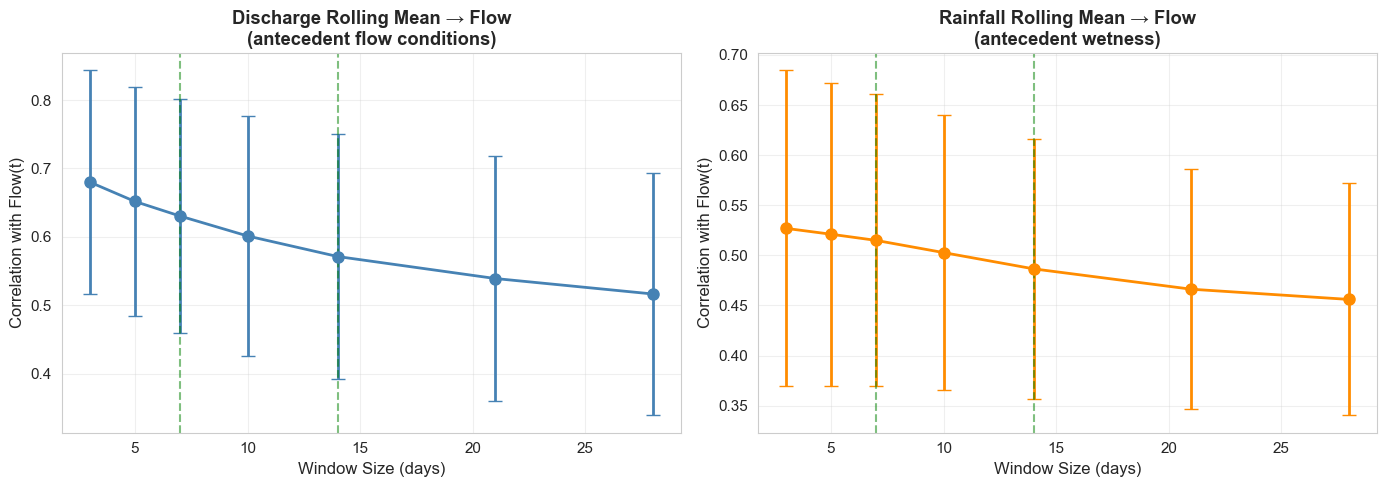

In [19]:
window_sizes = [3, 5, 7, 10, 14, 21, 28]

np.random.seed(42)
sample_sids = train['station_id'].unique()
if len(sample_sids) > 200:
    sample_sids = np.random.choice(sample_sids, 200, replace=False)

window_corrs = {w: [] for w in window_sizes}

for sid in sample_sids:
    sdata = train[train['station_id'] == sid][['flow', 'rainfall']].dropna()
    if len(sdata) < 100:
        continue
    
    for w in window_sizes:
        roll_flow = sdata['flow'].shift(1).rolling(w, min_periods=1).mean()
        roll_rain = sdata['rainfall'].shift(1).rolling(w, min_periods=1).mean()
        
        r_flow = roll_flow.corr(sdata['flow'])
        r_rain = roll_rain.corr(sdata['flow'])
        
        if not np.isnan(r_flow):
            window_corrs[w].append({'flow_corr': r_flow, 'rain_corr': r_rain})

window_summary = []
for w in window_sizes:
    if window_corrs[w]:
        df_w = pd.DataFrame(window_corrs[w])
        window_summary.append({
            'window': w,
            'flow_corr_mean': df_w['flow_corr'].mean(),
            'flow_corr_std': df_w['flow_corr'].std(),
            'rain_corr_mean': df_w['rain_corr'].mean(),
            'rain_corr_std': df_w['rain_corr'].std()
        })

ws_df = pd.DataFrame(window_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(ws_df['window'], ws_df['flow_corr_mean'], yerr=ws_df['flow_corr_std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='steelblue')
for w in [7, 14]:
    axes[0].axvline(w, color='green', ls='--', alpha=0.5)
axes[0].set_xlabel('Window Size (days)', fontsize=12)
axes[0].set_ylabel('Correlation with Flow(t)', fontsize=12)
axes[0].set_title('Discharge Rolling Mean → Flow\n(antecedent flow conditions)', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].errorbar(ws_df['window'], ws_df['rain_corr_mean'], yerr=ws_df['rain_corr_std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='darkorange')
for w in [7, 14]:
    axes[1].axvline(w, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Window Size (days)', fontsize=12)
axes[1].set_ylabel('Correlation with Flow(t)', fontsize=12)
axes[1].set_title('Rainfall Rolling Mean → Flow\n(antecedent wetness)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- clear diminishing returns: 3→7 days is large, 7→14 moderate, beyond 14 negligible.
- **7d window** captures current weather regime.
- **14d window** captures antecedent wetness — soil saturation state, governs whether new rainfall generates runoff or infiltrates.
- rainfall rolling windows have lower absolute correlation than discharge windows (expected as flow is autocorrelated by construction). but they matter more for residual prediction: "how much has it rained lately" is the antecedent-wetness signal the model needs after already seeing recent discharge.


37 features: 14 discharge lags, 14 rainfall lags, 4 rolling windows, 2 seasonal encodings, 3 static attributes. worth checking for problematic redundancy.

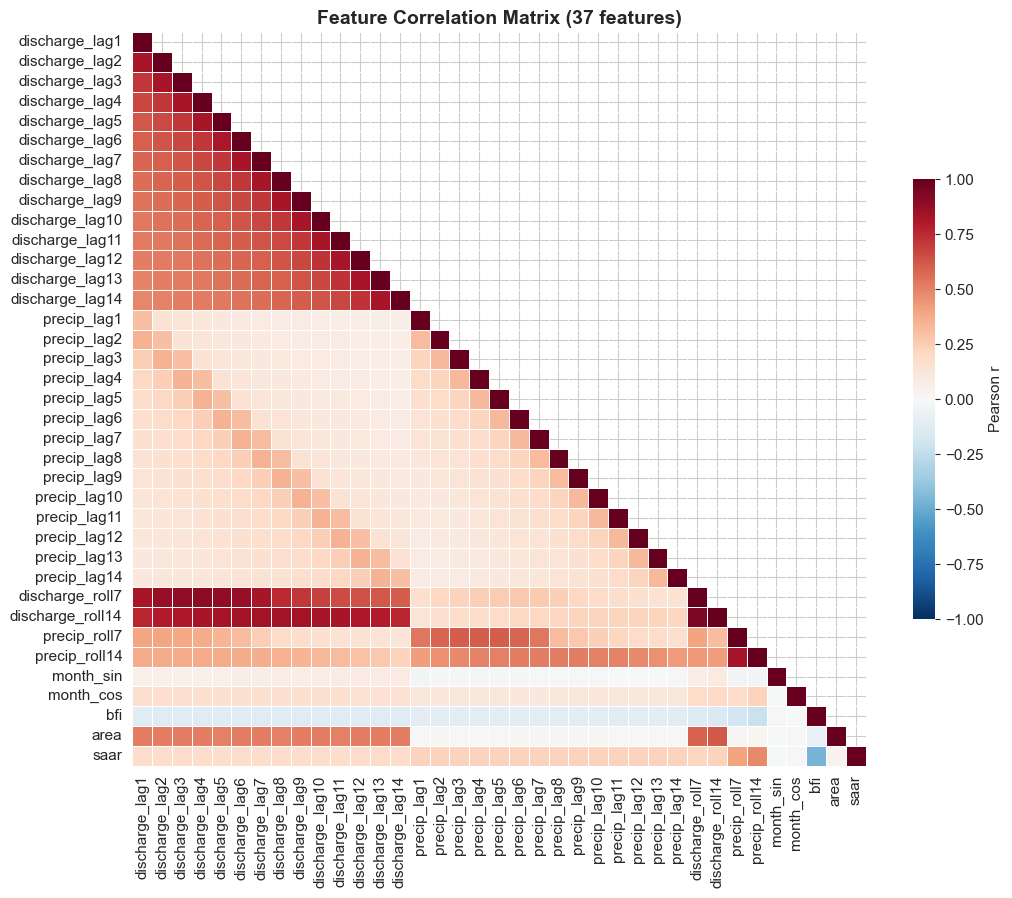

In [20]:
feature_cols = (
    [f'discharge_lag{i}' for i in range(1, 15)] +
    [f'precip_lag{i}' for i in range(1, 15)] +
    ['discharge_roll7', 'discharge_roll14', 'precip_roll7', 'precip_roll14'] +
    ['month_sin', 'month_cos', 'bfi', 'area', 'saar']
)

np.random.seed(42)
sample_idx = np.random.choice(len(train), min(500000, len(train)), replace=False)
sample_df = train.iloc[sample_idx][feature_cols].dropna()

corr = sample_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (37 features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../latex-report/figures/eda_feature_corrmatrix.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append({
                'feature_1': corr.index[i],
                'feature_2': corr.columns[j],
                'correlation': corr.iloc[i, j]
            })

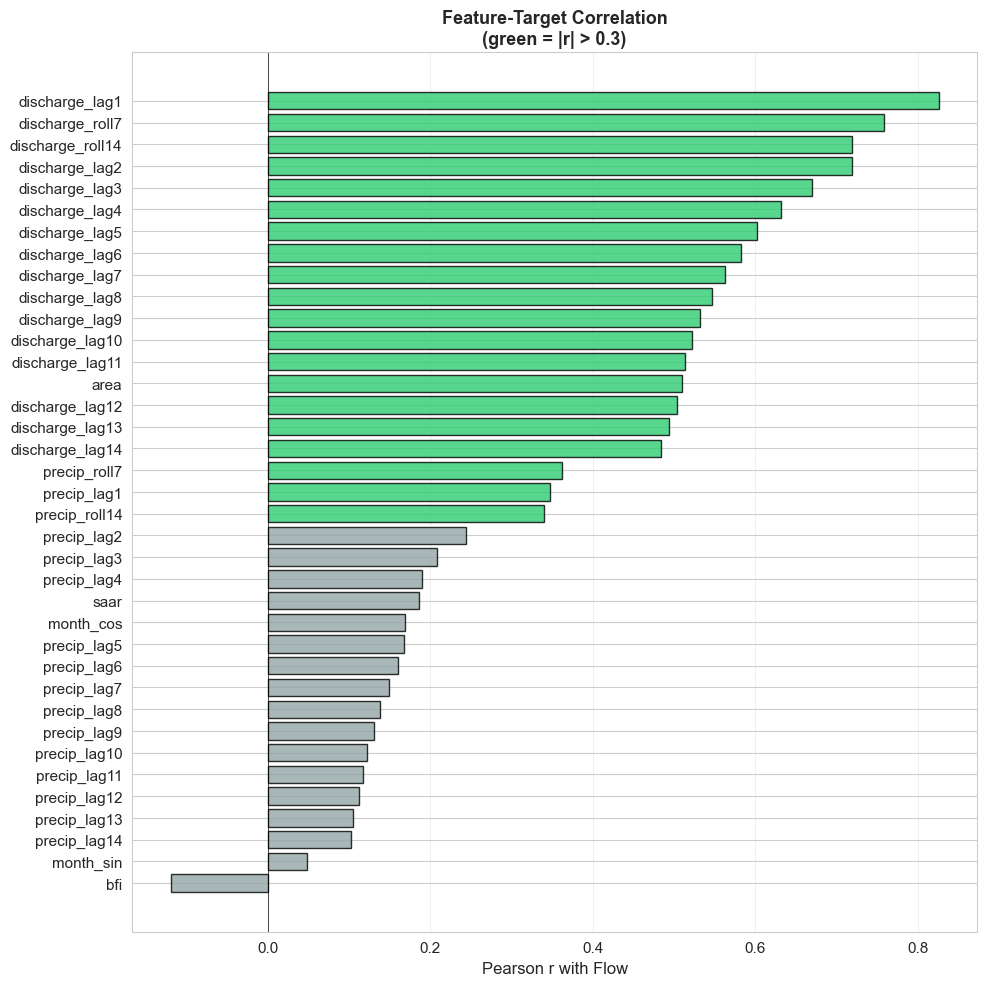


Strongest predictors of flow:
discharge_lag1      0.825630
discharge_roll7     0.758680
discharge_roll14    0.718848
discharge_lag2      0.718549
discharge_lag3      0.669236
discharge_lag4      0.632109
discharge_lag5      0.602331
discharge_lag6      0.582651
discharge_lag7      0.562586
discharge_lag8      0.547120

Note: discharge lags dominate (strong autocorrelation).
Rainfall features have lower raw correlation but add unique predictive information.


In [21]:
target_corr = sample_df.corrwith(train.iloc[sample_idx]['flow'].dropna()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if abs(v) > 0.3 else '#95a5a6' for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel('Pearson r with Flow', fontsize=12)
ax.set_title('Feature-Target Correlation\n(green = |r| > 0.3)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nStrongest predictors of flow:')
print(target_corr.head(10).to_string())
print(f'\nNote: discharge lags dominate (strong autocorrelation).')
print(f'Rainfall features have lower raw correlation but add unique predictive information.')

- Only one pair above |r| = 0.9: `discharge_roll7` vs `discharge_roll14` at 0.94 (7d window is a subset of 14d, so expected).
- Block-diagonal structure: discharge lags form a tight AR block (adjacent lags r = 0.85–0.95), rainfall lags a weaker block (r = 0.3–0.5, daily weather is stochastic), cross-blocks are low (rainfall carries independent information beyond flow history).
- Static features (BFI, area, SAAR) uncorrelated with all dynamic features — orthogonal subspace, as expected for time-invariant properties.
- `discharge_lag1` dominates target correlation at r = 0.83. Rainfall features look weak individually (r < 0.2), but their contribution is in the residual unexplained by flow history — substantial for low-BFI stations.
- Ridge handles the collinear lag block naturally, distributing weight smoothly rather than zeroing out individual lags as Lasso would.

## feature distributions and transformations

correlations tell us *what* predicts flow. distributions tell us *how* the model will see those inputs — skewed features concentrate most samples in a narrow band with long tails, making gradient-based learning inefficient. zero-inflated features (rainfall) create a discrete/continuous mixture that linear models handle poorly.

In [22]:
feature_groups = {
    'Discharge lags': [f'discharge_lag{i}' for i in range(1, 15)],
    'Precip lags': [f'precip_lag{i}' for i in range(1, 15)],
    'Rolling means': ['discharge_roll7', 'discharge_roll14', 'precip_roll7', 'precip_roll14'],
    'Seasonal': ['month_sin', 'month_cos'],
    'Static': ['bfi', 'area', 'saar'],
}

all_feats = [f for group in feature_groups.values() for f in group]
existing_feats = [f for f in all_feats if f in train.columns]

dist_stats = []
for feat in existing_feats:
    vals = train[feat].dropna()
    dist_stats.append({
        'feature': feat,
        'mean': vals.mean(),
        'std': vals.std(),
        'skewness': vals.skew(),
        'kurtosis': vals.kurtosis(),
        'zero_frac': (vals == 0).mean(),
        'min': vals.min(),
        'max': vals.max(),
        'N': len(vals),
    })

dist_df = pd.DataFrame(dist_stats)

dist_df['skew_flag'] = dist_df['skewness'].abs() > 2
dist_df['zero_flag'] = dist_df['zero_frac'] > 0.3

print('Feature distribution summary (146 benchmark stations, train period only)')
print('=' * 90)
print(dist_df[['feature', 'skewness', 'kurtosis', 'zero_frac', 'skew_flag', 'zero_flag']]
      .to_string(index=False, float_format='{:.2f}'.format))

n_skewed = dist_df['skew_flag'].sum()
n_zero = dist_df['zero_flag'].sum()
print(f'\n{n_skewed} features with |skewness| > 2 (heavy tail)')
print(f'{n_zero} features with >30% zeros (zero-inflated)')

Feature distribution summary (146 benchmark stations, train period only)
         feature  skewness  kurtosis  zero_frac  skew_flag  zero_flag
  discharge_lag1      8.26    134.73       0.00       True      False
  discharge_lag2      8.26    134.75       0.00       True      False
  discharge_lag3      8.26    134.76       0.00       True      False
  discharge_lag4      8.26    134.76       0.00       True      False
  discharge_lag5      8.27    134.77       0.00       True      False
  discharge_lag6      8.27    134.81       0.00       True      False
  discharge_lag7      8.27    134.88       0.00       True      False
  discharge_lag8      8.27    134.91       0.00       True      False
  discharge_lag9      8.27    134.91       0.00       True      False
 discharge_lag10      8.27    134.91       0.00       True      False
 discharge_lag11      8.27    134.91       0.00       True      False
 discharge_lag12      8.27    134.93       0.00       True      False
 discharge_lag13 

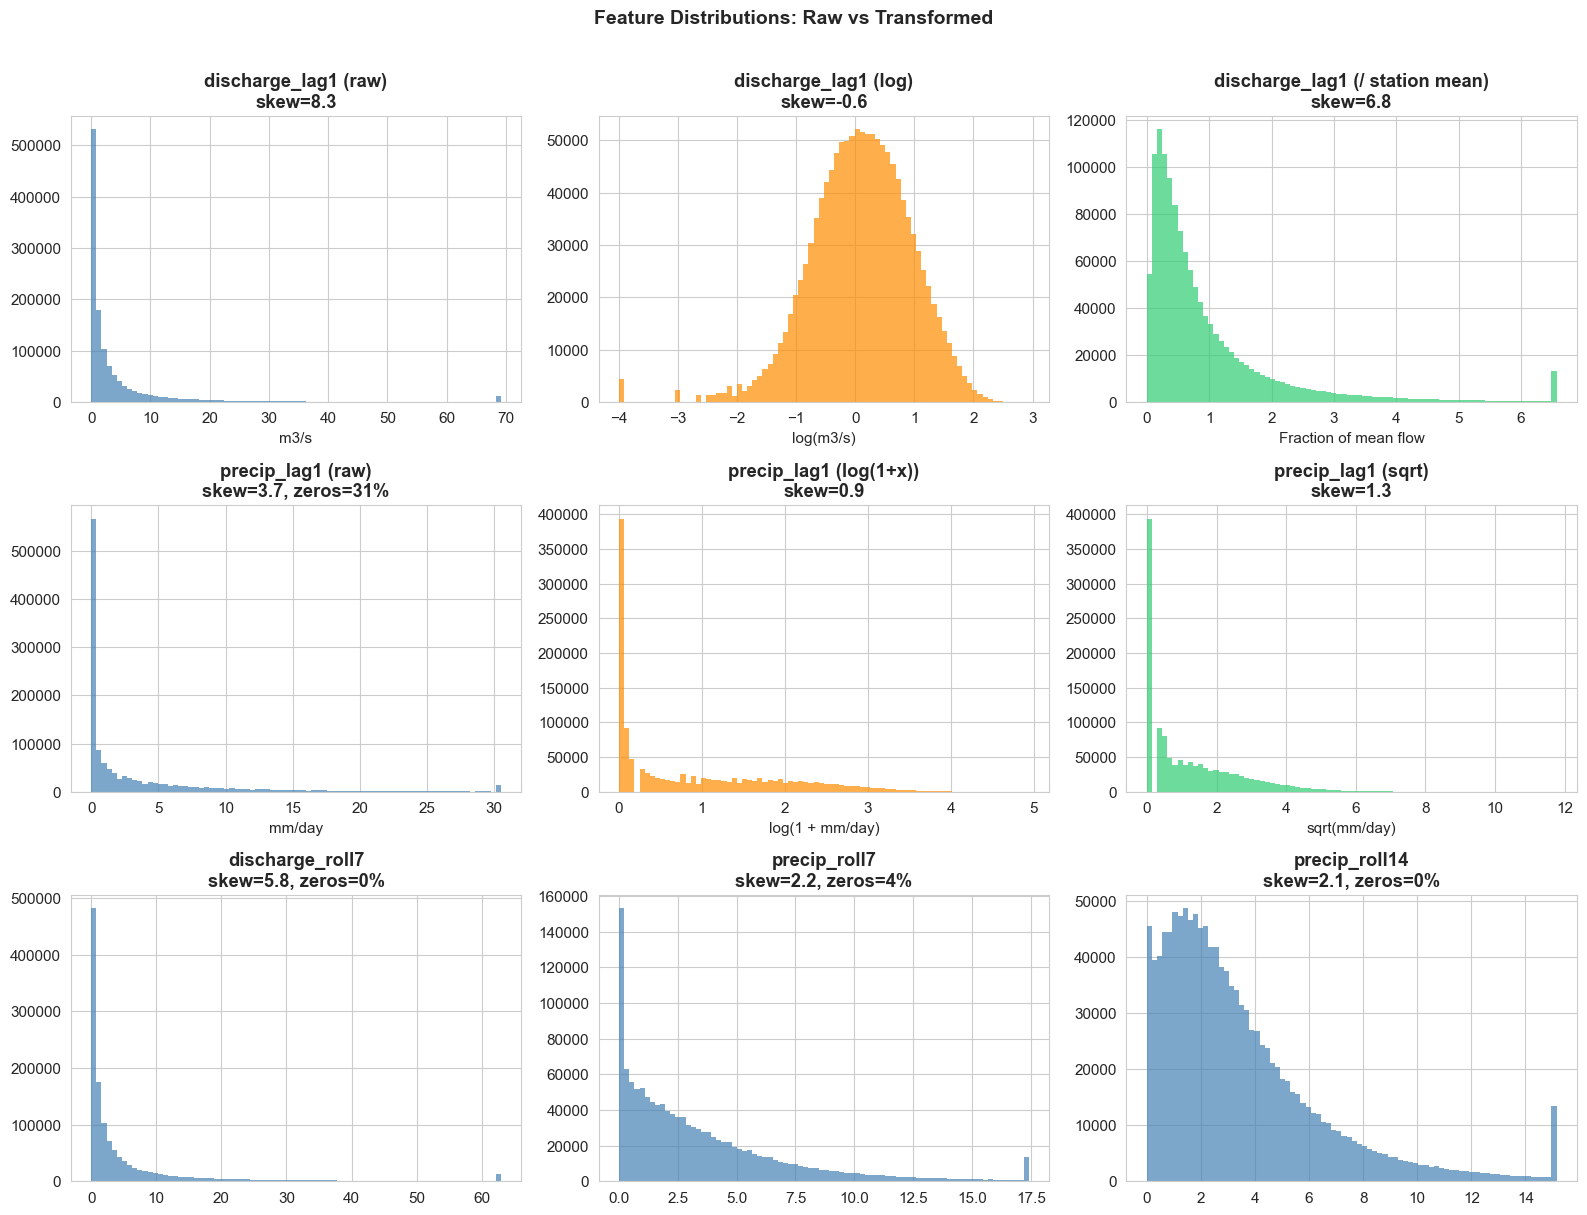

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

vals = train['discharge_lag1'].dropna()
vals_pos = vals.clip(lower=1e-4)

axes[0, 0].hist(vals.clip(upper=vals.quantile(0.99)), bins=80, color='steelblue',
                edgecolor='none', alpha=0.7)
axes[0, 0].set_title(f'discharge_lag1 (raw)\nskew={vals.skew():.1f}', fontweight='bold')
axes[0, 0].set_xlabel('m3/s')

axes[0, 1].hist(np.log1p(vals_pos), bins=80, color='darkorange', edgecolor='none', alpha=0.7)
axes[0, 1].set_title(f'discharge_lag1 (ln)\nskew={np.log1p(vals_pos).skew():.1f}', fontweight='bold')
axes[0, 1].set_xlabel('ln(1 + m³/s)')

norm_vals = train[['station_id', 'discharge_lag1']].dropna()
train_means = train.groupby('station_id')['flow'].mean()
norm_vals = norm_vals.copy()
norm_vals['normalised'] = norm_vals['discharge_lag1'] / norm_vals['station_id'].map(train_means)
norm_vals = norm_vals['normalised'].dropna()
norm_vals = norm_vals[np.isfinite(norm_vals)]
axes[0, 2].hist(norm_vals.clip(upper=norm_vals.quantile(0.99)), bins=80, color='#2ecc71',
                edgecolor='none', alpha=0.7)
axes[0, 2].set_title(f'discharge_lag1 (/ station mean)\nskew={norm_vals.skew():.1f}', fontweight='bold')
axes[0, 2].set_xlabel('Fraction of mean flow')

rain = train['precip_lag1'].dropna()
axes[1, 0].hist(rain.clip(upper=rain.quantile(0.99)), bins=80, color='steelblue',
                edgecolor='none', alpha=0.7)
axes[1, 0].set_title(f'precip_lag1 (raw)\nskew={rain.skew():.1f}, zeros={100*(rain==0).mean():.0f}%',
                      fontweight='bold')
axes[1, 0].set_xlabel('mm/day')

rain_log = np.log1p(rain)  # log(1 + x), safe for zeros
axes[1, 1].hist(rain_log, bins=80, color='darkorange', edgecolor='none', alpha=0.7)
axes[1, 1].set_title(f'precip_lag1 (log(1+x))\nskew={rain_log.skew():.1f}', fontweight='bold')
axes[1, 1].set_xlabel('ln(1 + mm/day)')

rain_sqrt = np.sqrt(rain)
axes[1, 2].hist(rain_sqrt, bins=80, color='#2ecc71', edgecolor='none', alpha=0.7)
axes[1, 2].set_title(f'precip_lag1 (sqrt)\nskew={rain_sqrt.skew():.1f}', fontweight='bold')
axes[1, 2].set_xlabel('sqrt(mm/day)')

for col_idx, feat in enumerate(['discharge_roll7', 'precip_roll7', 'precip_roll14']):
    vals = train[feat].dropna()
    axes[2, col_idx].hist(vals.clip(upper=vals.quantile(0.99)), bins=80, color='steelblue',
                          edgecolor='none', alpha=0.7)
    axes[2, col_idx].set_title(f'{feat}\nskew={vals.skew():.1f}, zeros={100*(vals==0).mean():.0f}%',
                                fontweight='bold')

plt.suptitle('Feature Distributions: Raw vs Transformed', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**discharge features:** raw skewness is extreme (~8+) because pooling 146 stations mixes scales. ln(1+Q) transform pulls skew to near zero but mixes stations in log-space. station-normalisation (dividing by train mean) is the best compromise — skewness drops substantially while keeping physical units interpretable. this is what we use in the pipeline.

**rainfall features:** zero-inflated — most days are dry. log(1+x) helps the tail but can't fix the spike at zero. sqrt is a gentler compromise. for linear models (Ridge), either transform works. for LSTMs, raw rainfall is fine since the network learns its own internal transformations. key insight: rolling means (7d, 14d) smooth out the zero-inflation problem naturally.

**rolling means:** discharge rolling means inherit skewness from raw flow but are smoother. rainfall rolling means have far fewer zeros than daily rainfall — aggregation solves the zero-inflation issue.

## rainfall zero-inflation

daily rainfall is a mixture distribution: a point mass at zero (dry days) and a continuous distribution for wet days. this matters because a model trained on MSE will learn "predict zero rainfall effect" as a safe default.

Rainfall zero-inflation analysis
      feature  zero_frac  near_zero_frac  mean_when_wet  skew_all  skew_wet_only
  precip_lag1      0.309           0.309          5.080     3.729          3.216
  precip_lag2      0.309           0.309          5.080     3.729          3.216
  precip_lag3      0.309           0.309          5.079     3.730          3.217
  precip_lag4      0.310           0.310          5.079     3.730          3.217
  precip_lag5      0.310           0.310          5.080     3.730          3.217
  precip_lag6      0.310           0.310          5.079     3.731          3.218
  precip_lag7      0.310           0.310          5.078     3.732          3.219
  precip_lag8      0.310           0.310          5.077     3.732          3.219
  precip_lag9      0.310           0.310          5.077     3.732          3.219
 precip_lag10      0.310           0.310          5.078     3.732          3.218
 precip_lag11      0.310           0.310          5.078     3.732          3

/Users/aayush/Documents/deep-learning-exp/.venv/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


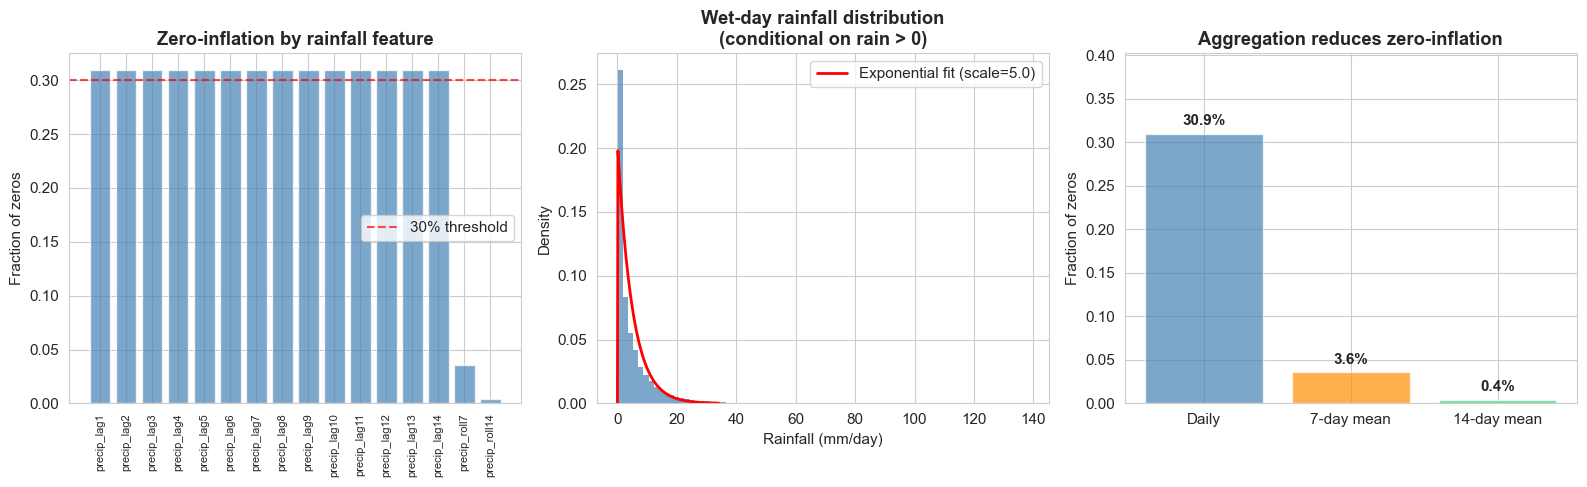

In [24]:
rain_feats = [f'precip_lag{i}' for i in range(1, 15)] + ['precip_roll7', 'precip_roll14']

zero_fracs = []
for feat in rain_feats:
    if feat in train.columns:
        vals = train[feat].dropna()
        zero_fracs.append({
            'feature': feat,
            'zero_frac': (vals == 0).mean(),
            'near_zero_frac': (vals < 0.1).mean(),
            'mean_when_wet': vals[vals > 0].mean() if (vals > 0).any() else np.nan,
            'skew_all': vals.skew(),
            'skew_wet_only': vals[vals > 0].skew() if (vals > 0).sum() > 10 else np.nan,
        })

zf_df = pd.DataFrame(zero_fracs)
print('Rainfall zero-inflation analysis')
print('=' * 85)
print(zf_df.to_string(index=False, float_format='{:.3f}'.format))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(range(len(zf_df)), zf_df['zero_frac'], color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(zf_df)))
axes[0].set_xticklabels(zf_df['feature'], rotation=90, fontsize=8)
axes[0].set_ylabel('Fraction of zeros')
axes[0].set_title('Zero-inflation by rainfall feature', fontweight='bold')
axes[0].axhline(0.3, color='red', ls='--', alpha=0.7, label='30% threshold')
axes[0].legend()

rain_wet = train['precip_lag1'].dropna()
rain_wet = rain_wet[rain_wet > 0]
axes[1].hist(rain_wet, bins=80, color='steelblue', edgecolor='none', alpha=0.7, density=True)
axes[1].hist(rain_wet, bins=80, color='darkorange', edgecolor='none', alpha=0.4, density=True,
             weights=np.ones(len(rain_wet)) * 0)  # placeholder
from scipy.stats import expon
loc, scale = expon.fit(rain_wet)
x_fit = np.linspace(0, rain_wet.quantile(0.99), 200)
axes[1].plot(x_fit, expon.pdf(x_fit, loc, scale), 'r-', lw=2, label=f'Exponential fit (scale={scale:.1f})')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Density')
axes[1].set_title('Wet-day rainfall distribution\n(conditional on rain > 0)', fontweight='bold')
axes[1].legend()

roll_feats = ['precip_lag1', 'precip_roll7', 'precip_roll14']
roll_zeros = [(train[f].dropna() == 0).mean() for f in roll_feats if f in train.columns]
roll_labels = ['Daily', '7-day mean', '14-day mean']
bars = axes[2].bar(roll_labels, roll_zeros, color=['steelblue', 'darkorange', '#2ecc71'], alpha=0.7)
for bar, val in zip(bars, roll_zeros):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', fontweight='bold')
axes[2].set_ylabel('Fraction of zeros')
axes[2].set_title('Aggregation reduces zero-inflation', fontweight='bold')
axes[2].set_ylim(0, max(roll_zeros) * 1.3)

plt.tight_layout()
plt.show()

- daily rainfall lags all have similar zero-fractions (~30-40% dry days in the UK). the wet-day distribution is approximately exponential — many light rain days, few heavy ones.
- rolling means dramatically reduce zeros: 7-day mean has far fewer zero entries, 14-day mean has almost none. this is why rolling features are more useful than individual lags for linear models — they provide a continuous "antecedent wetness" signal.
- for the LSTM: raw daily rainfall is fine as input (the recurrent structure learns its own smoothing). for Ridge: rolling means are preferable as they're better conditioned.

## static attribute distributions

the three static features (BFI, area, SAAR) enter the model as constant vectors per station. their distributions across the 146 benchmark stations determine whether normalisation or transformation is needed.

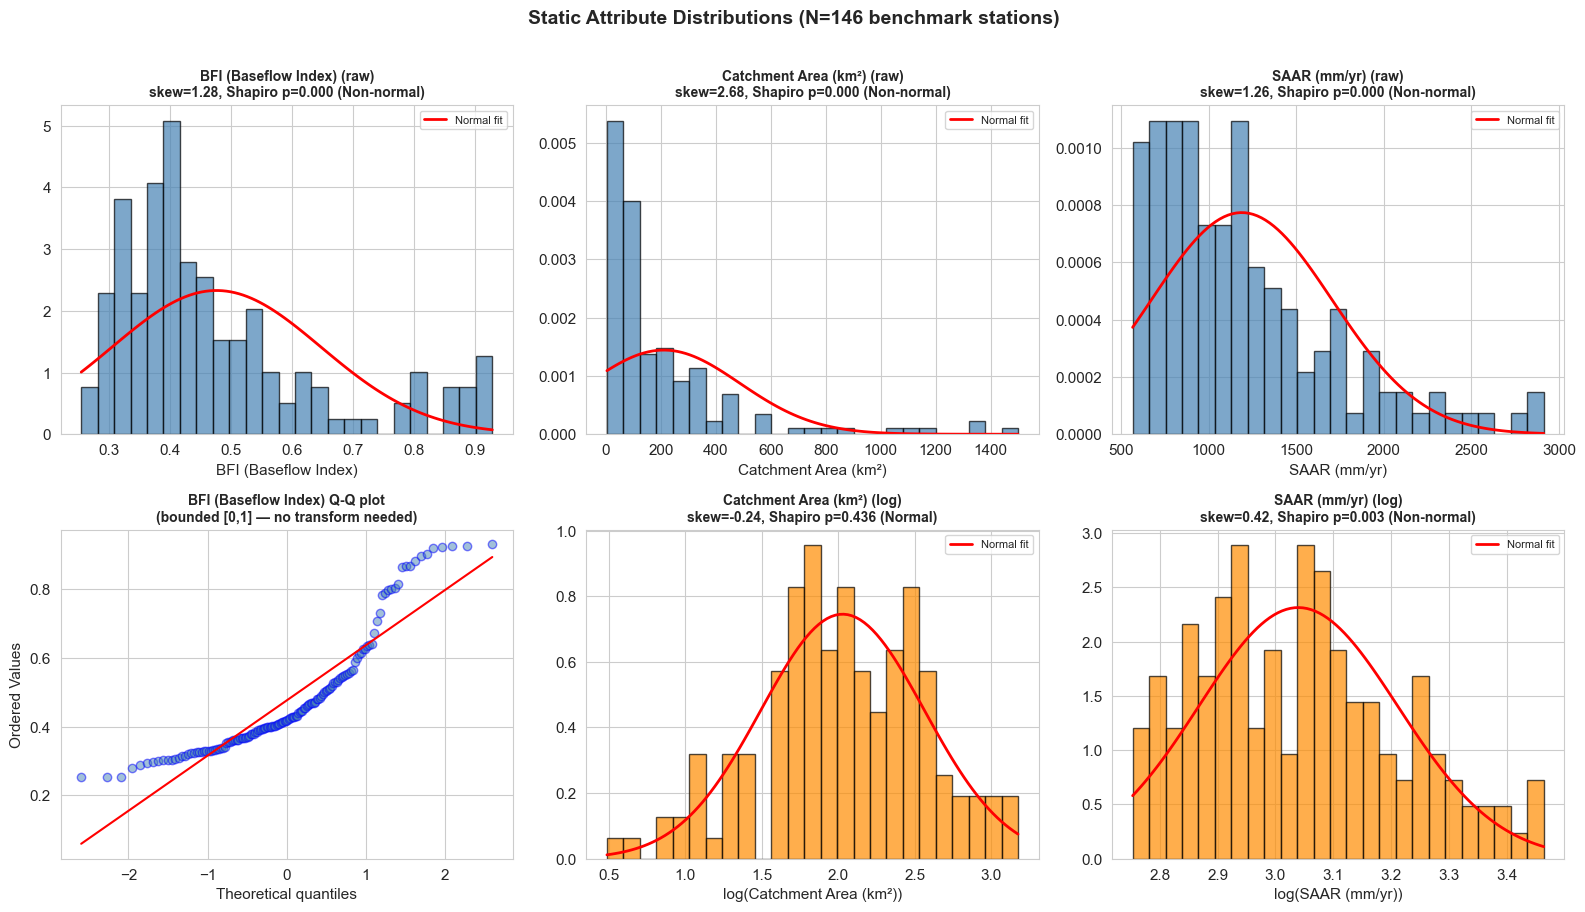


Static attribute summary:
  BFI (Baseflow Index)            range [0.3, 0.9]  skew=1.28  N=146
  Catchment Area (km²)            range [3.1, 1500.0]  skew=2.68  N=146
  SAAR (mm/yr)                    range [566.0, 2913.0]  skew=1.26  N=146


In [25]:
static_feats = {
    'bfi': {'col': 'bfihost19', 'label': 'BFI (Baseflow Index)', 'transforms': ['raw']},
    'area': {'col': 'catchment-area', 'label': 'Catchment Area (km²)', 'transforms': ['raw', 'log10']},
    'saar': {'col': 'saar-1961-1990', 'label': 'SAAR (mm/yr)', 'transforms': ['raw', 'log10']},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_idx, (key, info) in enumerate(static_feats.items()):
    col = info['col']
    vals = meta[col].dropna()
    
    axes[0, col_idx].hist(vals, bins=25, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    
    mu, sigma = vals.mean(), vals.std()
    x_fit = np.linspace(vals.min(), vals.max(), 100)
    axes[0, col_idx].plot(x_fit, stats.norm.pdf(x_fit, mu, sigma), 'r-', lw=2, label='Normal fit')
    
    if len(vals) <= 5000:
        sw_stat, sw_p = stats.shapiro(vals)
        normal_str = 'Normal' if sw_p > 0.05 else 'Non-normal'
    else:
        sw_p = 0
        normal_str = '(too large for Shapiro)'
    
    axes[0, col_idx].set_title(f'{info["label"]} (raw)\nskew={vals.skew():.2f}, Shapiro p={sw_p:.3f} ({normal_str})',
                                fontweight='bold', fontsize=10)
    axes[0, col_idx].set_xlabel(info['label'])
    axes[0, col_idx].legend(fontsize=8)
    
    if 'log10' in info['transforms']:
        log_vals = np.log10(vals.clip(lower=1e-4))
        axes[1, col_idx].hist(log_vals, bins=25, color='darkorange', edgecolor='black', alpha=0.7, density=True)
        
        mu_log, sigma_log = log_vals.mean(), log_vals.std()
        x_fit_log = np.linspace(log_vals.min(), log_vals.max(), 100)
        axes[1, col_idx].plot(x_fit_log, stats.norm.pdf(x_fit_log, mu_log, sigma_log),
                              'r-', lw=2, label='Normal fit')
        
        sw_stat_log, sw_p_log = stats.shapiro(log_vals)
        normal_str_log = 'Normal' if sw_p_log > 0.05 else 'Non-normal'
        
        axes[1, col_idx].set_title(f'{info["label"]} (ln)\nskew={log_vals.skew():.2f}, Shapiro p={sw_p_log:.3f} ({normal_str_log})',
                                    fontweight='bold', fontsize=10)
        axes[1, col_idx].set_xlabel(f'log({info["label"]})')
        axes[1, col_idx].legend(fontsize=8)
    else:
        stats.probplot(vals, dist='norm', plot=axes[1, col_idx])
        axes[1, col_idx].set_title(f'{info["label"]} Q-Q plot\n(bounded [0,1] — no transform needed)',
                                    fontweight='bold', fontsize=10)
        axes[1, col_idx].get_lines()[0].set_markerfacecolor('steelblue')
        axes[1, col_idx].get_lines()[0].set_alpha(0.5)

plt.suptitle(f'Static Attribute Distributions (N={len(meta)} benchmark stations)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nStatic attribute summary:')
for key, info in static_feats.items():
    vals = meta[info['col']].dropna()
    print(f'  {info["label"]:30s}  range [{vals.min():.1f}, {vals.max():.1f}]  '
          f'skew={vals.skew():.2f}  N={len(vals)}')

- **BFI:** bounded [0, 1], roughly uniform across benchmark stations with slight clustering around 0.4–0.6. no transform needed — already well-scaled. Q-Q plot may show light tails at extremes (few very flashy or very chalky benchmark catchments).
- **Catchment area:** massively right-skewed raw (few huge catchments, many small). ln transform makes it approximately normal and hence we should use log(area) in the model.
- **SAAR:** moderate right-skew raw (wet upland stations pull the tail). ln reduces skew. however, the improvement is modest. SAAR may be fine raw with z-score standardisation. we use log(SAAR) to be consistent with the area treatment and because rainfall-runoff relationships are multiplicative.

---
## 10. per-station target distribution

the target is ln(1+Q). pooled analysis (section 1) showed it's near-normal, but that mixes 146 stations. does the transform work equally well for each station, or do some catchment types resist normalisation?

/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/1104576480.py:56: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/fq/f40cv5nn127f5sjr8rf6vk580000gn/T/ipykernel_30878/1104576480.py:56: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


/Users/aayush/Documents/deep-learning-exp/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aayush/Documents/deep-learning-exp/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


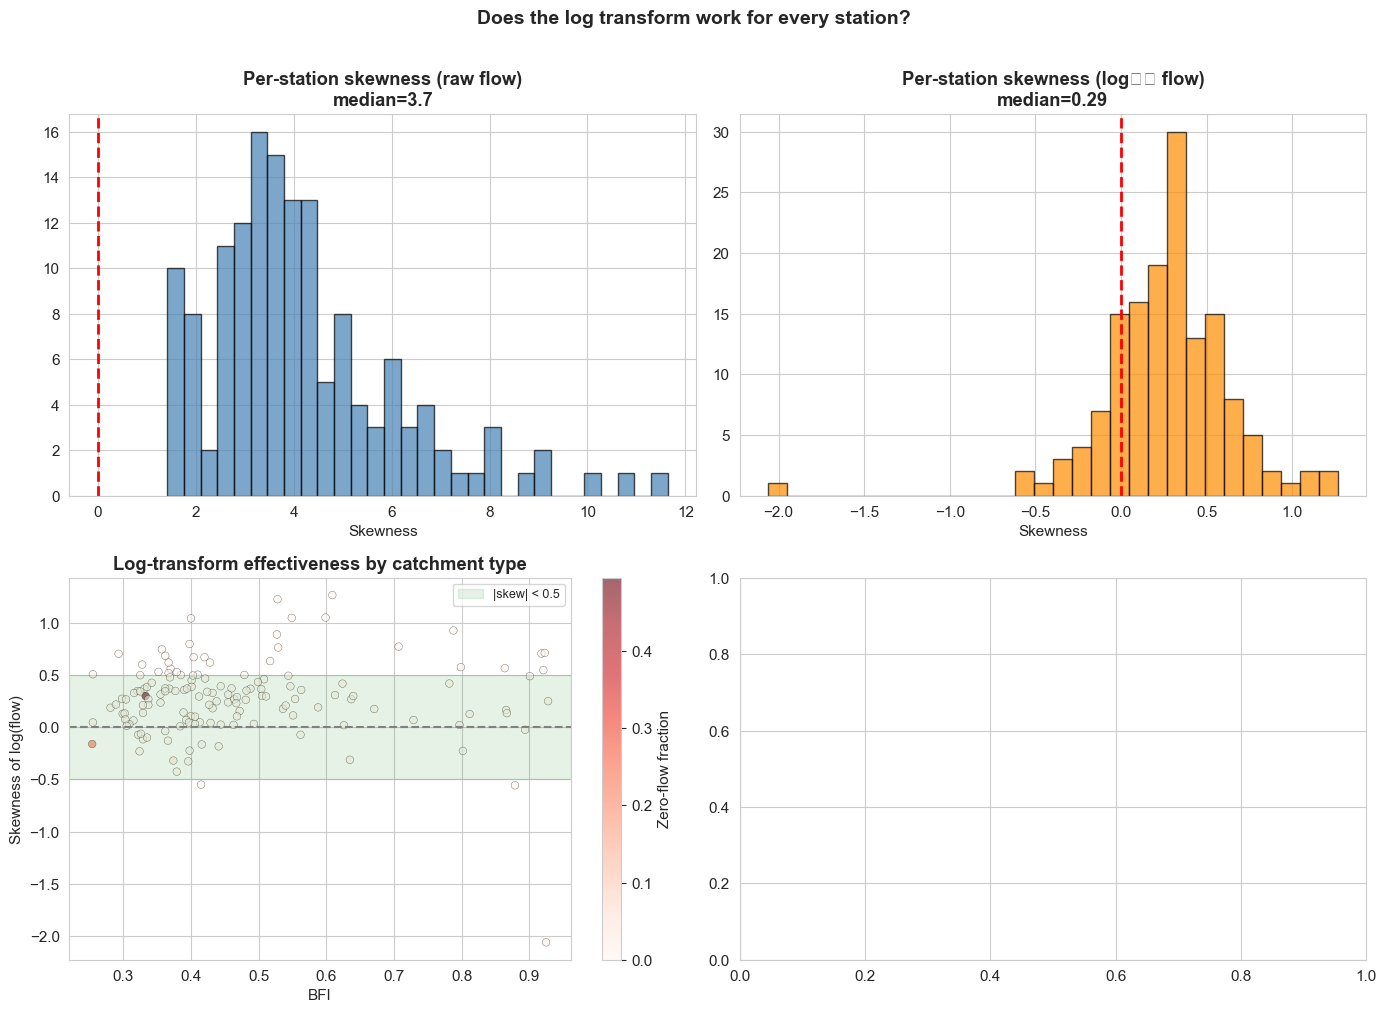


Stations where log transform works worst (highest residual skewness):
 station_id   bfi  log_skew  zero_flow_frac  shapiro_p
      41027 0.609     1.267           0.000      0.000
      45005 0.528     1.227           0.000      0.000
      28072 0.599     1.052           0.000      0.000
      36003 0.549     1.049           0.000      0.000
      32003 0.400     1.044           0.000      0.000


In [26]:
station_dist = []
for sid in train['station_id'].unique():
    sflow = train[train['station_id'] == sid]['flow'].dropna()
    if len(sflow) < 365:
        continue
    
    log_flow = np.log1p(sflow)
    
    sample = log_flow.sample(min(len(log_flow), 5000), random_state=42)
    sw_stat, sw_p = stats.shapiro(sample)
    
    station_dist.append({
        'station_id': sid,
        'n_obs': len(sflow),
        'raw_skew': sflow.skew(),
        'raw_kurtosis': sflow.kurtosis(),
        'log_skew': log_flow.skew(),
        'log_kurtosis': log_flow.kurtosis(),
        'shapiro_p': sw_p,
        'zero_flow_frac': (sflow <= 0.001).mean(),
    })

sdist = pd.DataFrame(station_dist)
sdist = sdist.merge(meta_bfi, on='station_id', how='left')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(sdist['raw_skew'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', ls='--', lw=2)
axes[0, 0].set_xlabel('Skewness')
axes[0, 0].set_title(f'Per-station skewness (raw flow)\nmedian={sdist["raw_skew"].median():.1f}',
                      fontweight='bold')

axes[0, 1].hist(sdist['log_skew'], bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', ls='--', lw=2)
axes[0, 1].set_xlabel('Skewness')
axes[0, 1].set_title(f'Per-station skewness (ln(1+Q))\nmedian={sdist["log_skew"].median():.2f}',
                      fontweight='bold')

sc = axes[1, 0].scatter(sdist['bfi'], sdist['log_skew'], c=sdist['zero_flow_frac'],
                        cmap='Reds', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[1, 0].axhline(0, color='grey', ls='--')
axes[1, 0].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='|skew| < 0.5')
axes[1, 0].set_xlabel('BFI')
axes[1, 0].set_ylabel('Skewness of ln(1+Q)')
axes[1, 0].set_title('ln(1+Q) transform effectiveness by catchment type', fontweight='bold')
axes[1, 0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[1, 0], label='Zero-flow fraction')

plt.suptitle('Does the ln(1+Q) transform work for every station?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

worst = sdist.nlargest(5, 'log_skew')[['station_id', 'bfi', 'log_skew', 'zero_flow_frac', 'shapiro_p']]
print('\nStations where ln(1+Q) transform works worst (highest residual skewness):')
print(worst.to_string(index=False, float_format='{:.3f}'.format))

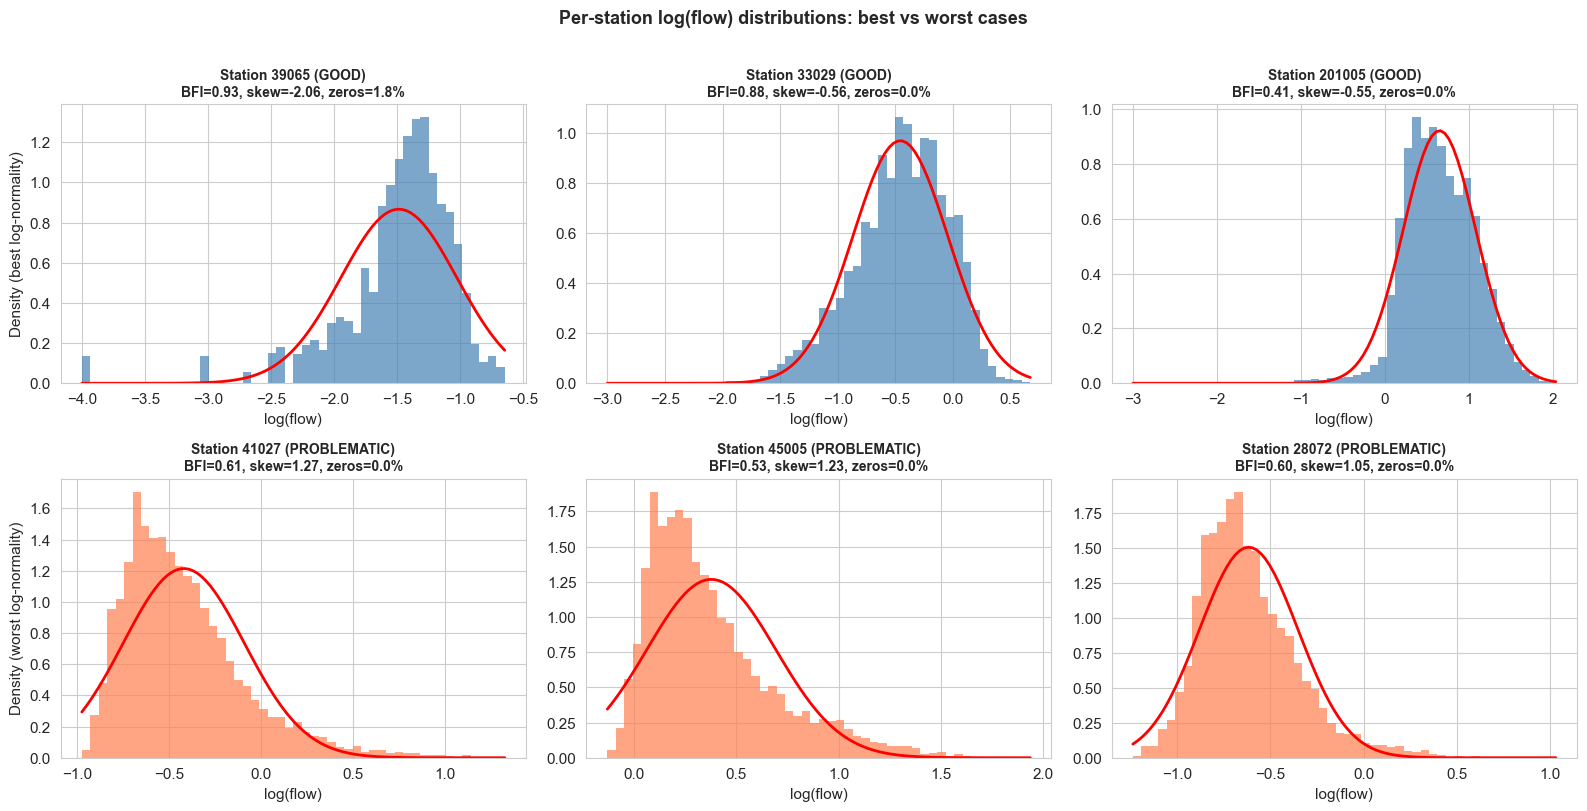

In [27]:
best_stations = sdist.nsmallest(3, 'log_skew')['station_id'].tolist()
worst_stations = sdist.nlargest(3, 'log_skew')['station_id'].tolist()
example_stations = best_stations + worst_stations

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, sid in enumerate(example_stations):
    row = idx // 3
    col = idx % 3
    
    sflow = train[train['station_id'] == sid]['flow'].dropna()
    log_flow = np.log1p(sflow)
    bfi_val = sdist[sdist['station_id'] == sid]['bfi'].iloc[0]
    skew_val = sdist[sdist['station_id'] == sid]['log_skew'].iloc[0]
    zf = sdist[sdist['station_id'] == sid]['zero_flow_frac'].iloc[0]
    
    axes[row, col].hist(log_flow, bins=50, color='steelblue' if row == 0 else 'coral',
                        edgecolor='none', alpha=0.7, density=True)
    
    mu, sigma = log_flow.mean(), log_flow.std()
    x = np.linspace(log_flow.min(), log_flow.max(), 100)
    axes[row, col].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
    
    label = 'GOOD' if row == 0 else 'PROBLEMATIC'
    axes[row, col].set_title(f'Station {sid} ({label})\nBFI={bfi_val:.2f}, skew={skew_val:.2f}, zeros={zf:.1%}',
                              fontweight='bold', fontsize=10)
    axes[row, col].set_xlabel('ln(1+Q)')

axes[0, 0].set_ylabel('Density (best normality)')
axes[1, 0].set_ylabel('Density (worst normality)')

plt.suptitle('Per-station ln(1+Q) distributions: best vs worst cases',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

- ln(1+Q) transform dramatically reduces skewness for the vast majority of stations (raw median skew ~4-5 → log median skew near 0).
- problematic stations cluster at low BFI with non-zero "zero-flow fraction" - ephemeral or near-ephemeral streams where the log transform creates a spike at the clipping boundary (log(1e-4) = -4). these are the hardest stations to model with any approach.
- **implication:** ln(1 + Q) is a good default target transform. for the handful of near-zero-flow stations

## temporal stationarity and train/val/test split consistency

the pipeline uses temporal splits — train on early years, validate on middle years, test on recent years. this assumes the distribution of flow doesn't change over time. with 30 years of data (1994–2024) spanning observable changes in UK rainfall patterns, that assumption needs checking.

Train: 1994-01-01 to 2017-12-31  (24 years, 1,279,836 rows)
Val:   2018-01-01 to 2019-12-31  (2 years, 106,580 rows)
Test:  2020-01-01 to 2024-09-30  (5 years, 251,712 rows)


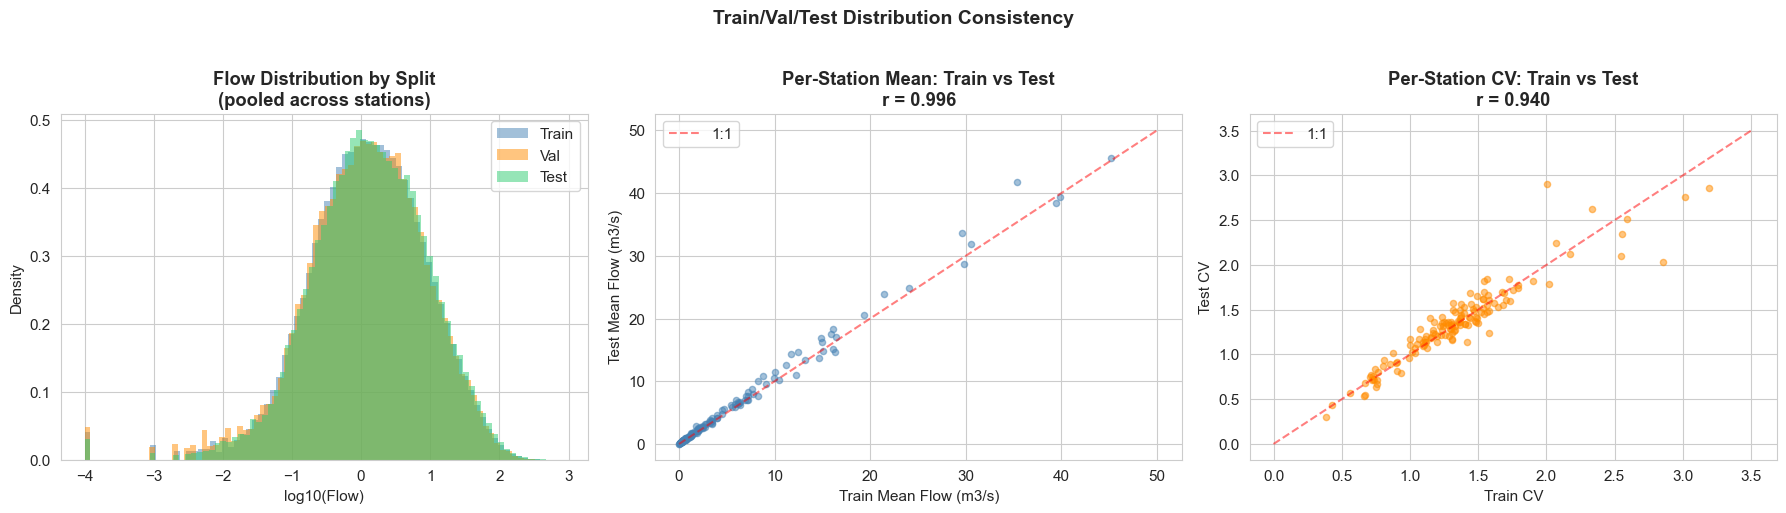

In [28]:
val_all = pd.read_feather('../checkpoints/val_data.feather')
test_all = pd.read_feather('../checkpoints/test_data.feather')
val_all['date'] = pd.to_datetime(val_all['date'])
test_all['date'] = pd.to_datetime(test_all['date'])

val = val_all[val_all['station_id'].isin(bench_ids)].copy()
test = test_all[test_all['station_id'].isin(bench_ids)].copy()

print(f'Train: {train["date"].min().date()} to {train["date"].max().date()}  '
      f'({train["date"].dt.year.nunique()} years, {len(train):,} rows)')
print(f'Val:   {val["date"].min().date()} to {val["date"].max().date()}  '
      f'({val["date"].dt.year.nunique()} years, {len(val):,} rows)')
print(f'Test:  {test["date"].min().date()} to {test["date"].max().date()}  '
      f'({test["date"].dt.year.nunique()} years, {len(test):,} rows)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, df, color in [('Train', train, 'steelblue'),
                           ('Val', val, 'darkorange'),
                           ('Test', test, '#2ecc71')]:
    flow_log = np.log1p(df['flow'].dropna())
    axes[0].hist(flow_log, bins=80, density=True, alpha=0.5, label=label, color=color, edgecolor='none')

axes[0].set_xlabel('ln(1+Q)')
axes[0].set_ylabel('Density')
axes[0].set_title('Flow Distribution by Split\n(pooled across stations)', fontweight='bold')
axes[0].legend()

train_means = train.groupby('station_id')['flow'].mean()
test_means = test.groupby('station_id')['flow'].mean()
common = train_means.index.intersection(test_means.index)

axes[1].scatter(train_means[common], test_means[common], alpha=0.5, s=20, c='steelblue')
lims = [0, max(train_means[common].max(), test_means[common].max()) * 1.1]
axes[1].plot(lims, lims, 'r--', alpha=0.5, label='1:1')
r_means = train_means[common].corr(test_means[common])
axes[1].set_xlabel('Train Mean Flow (m3/s)')
axes[1].set_ylabel('Test Mean Flow (m3/s)')
axes[1].set_title(f'Per-Station Mean: Train vs Test\nr = {r_means:.3f}', fontweight='bold')
axes[1].legend()

train_cv = train.groupby('station_id')['flow'].agg(lambda x: x.std() / x.mean())
test_cv = test.groupby('station_id')['flow'].agg(lambda x: x.std() / x.mean())
common_cv = train_cv.index.intersection(test_cv.index)

axes[2].scatter(train_cv[common_cv], test_cv[common_cv], alpha=0.5, s=20, c='darkorange')
lims_cv = [0, max(train_cv[common_cv].max(), test_cv[common_cv].max()) * 1.1]
axes[2].plot(lims_cv, lims_cv, 'r--', alpha=0.5, label='1:1')
r_cv = train_cv[common_cv].corr(test_cv[common_cv])
axes[2].set_xlabel('Train CV')
axes[2].set_ylabel('Test CV')
axes[2].set_title(f'Per-Station CV: Train vs Test\nr = {r_cv:.3f}', fontweight='bold')
axes[2].legend()

plt.suptitle('Train/Val/Test Distribution Consistency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- each station's mean flow is determined by physical properties (catchment area, geology, rainfall climate) that don't change between decades
- a 500 km2 catchment in Wales will have high mean flow whether you look at 1990–2010 or 2010–2020
- if correlation was low it would be alarming because it means stations fundamentally changed character between periods and thus breaking the stationarity assumption

we expect cv to be harder to estimate as a single extreme flood landing in one period but not the other shifts it so this is expected. the same dates don't appear in both train and test, the lags also go backward only

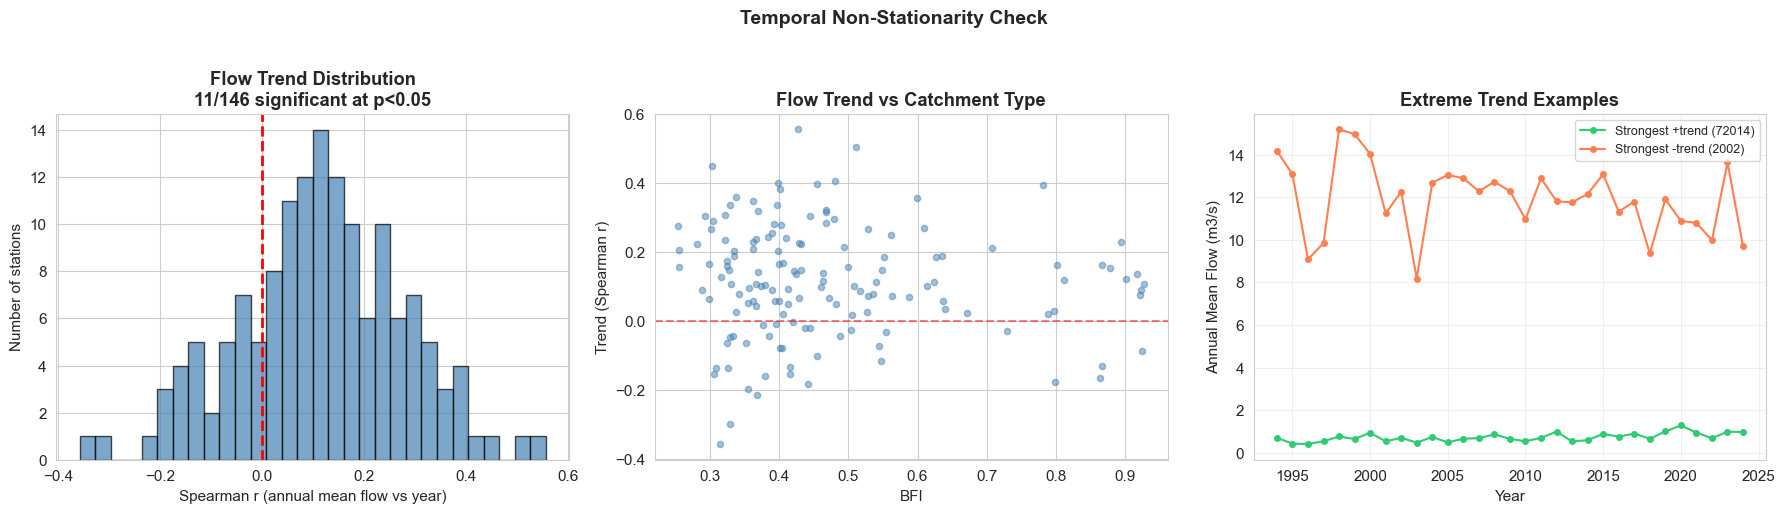


Median trend: r = +0.111
Significant trends (p<0.05): 11/146 stations (8%)
Most stations show no significant trend — temporal split assumption is reasonable.


In [29]:
ts_bench = ts.copy()
ts_bench['year'] = ts_bench['date'].dt.year

annual_mean = ts_bench.groupby(['station_id', 'year'])['flow'].mean().reset_index()
annual_mean = annual_mean.merge(meta_bfi, on='station_id', how='left')

from scipy.stats import spearmanr

trends = []
for sid in annual_mean['station_id'].unique():
    sdata = annual_mean[annual_mean['station_id'] == sid].dropna(subset=['flow'])
    if len(sdata) < 10:
        continue
    r, p = spearmanr(sdata['year'], sdata['flow'])
    trends.append({'station_id': sid, 'trend_r': r, 'trend_p': p})

trend_df = pd.DataFrame(trends).merge(meta_bfi, on='station_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(trend_df['trend_r'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', ls='--', lw=2)
n_sig = (trend_df['trend_p'] < 0.05).sum()
axes[0].set_xlabel('Spearman r (annual mean flow vs year)')
axes[0].set_ylabel('Number of stations')
axes[0].set_title(f'Flow Trend Distribution\n{n_sig}/{len(trend_df)} significant at p<0.05',
                  fontweight='bold')

axes[1].scatter(trend_df['bfi'], trend_df['trend_r'], alpha=0.5, s=20, c='steelblue')
axes[1].axhline(0, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('BFI')
axes[1].set_ylabel('Trend (Spearman r)')
axes[1].set_title('Flow Trend vs Catchment Type', fontweight='bold')

strongest_up = trend_df.loc[trend_df['trend_r'].idxmax(), 'station_id']
strongest_down = trend_df.loc[trend_df['trend_r'].idxmin(), 'station_id']

for sid, color, label in [(strongest_up, '#2ecc71', 'Strongest +trend'), (strongest_down, 'coral', 'Strongest -trend')]:
    sdata = annual_mean[annual_mean['station_id'] == sid]
    axes[2].plot(sdata['year'], sdata['flow'], 'o-', color=color, label=f'{label} ({sid})',
                 markersize=4, linewidth=1.5)

axes[2].set_xlabel('Year')
axes[2].set_ylabel('Annual Mean Flow (m3/s)')
axes[2].set_title('Extreme Trend Examples', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Temporal Non-Stationarity Check', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

median_trend = trend_df['trend_r'].median()
print(f'\nMedian trend: r = {median_trend:+.3f}')
print(f'Significant trends (p<0.05): {n_sig}/{len(trend_df)} stations ({n_sig/len(trend_df)*100:.0f}%)')
print(f'Most stations show no significant trend — temporal split assumption is reasonable.')

- **split distributions:** if the pooled log-flow histograms overlap closely across train/val/test, the temporal split is not creating a distribution shift. per-station mean and CV scatters close to the 1:1 line confirm station-level consistency.
- **temporal trends:** most benchmark stations should show no significant trend over 30 years — these are near-natural catchments selected precisely for stability. if a small minority show trends, it's likely genuine climate signal (wetter winters, drier summers) rather than gauge drift.
- **implication for modelling:** if distributions are consistent and trends are rare, the stationarity assumption underlying the temporal split is defensible. any model performance degradation from train to test reflects genuine forecasting difficulty, not distribution shift.